In [138]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import function as f

sns.set_theme(style="ticks")


In [139]:
# --- user inputs ---
year = 2017
option = 'mean'  #optimization strategy
shift = -5 #shifting to EST from UTC
roll = 5
wthresh = 25
figformat = 'pdf'
dpi=500

# select figures to plot
figure1   = True 
figure2_5 = True #You get fig 5 for free with fig 2
figure3   = True
figure4   = True

figpath = '../../results/'
path = '../../data/GCdata/'


In [140]:
# --- global inputs ---
#locations of sites, lon/lat (°)
bronx = [-73.8782,40.8680]
nbrunswick = [-74.4226,40.4728]
underhill = [-72.8684,44.5283]
huntington = [-74.2231,43.9731]

/tmp/ipykernel_907/160772127.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


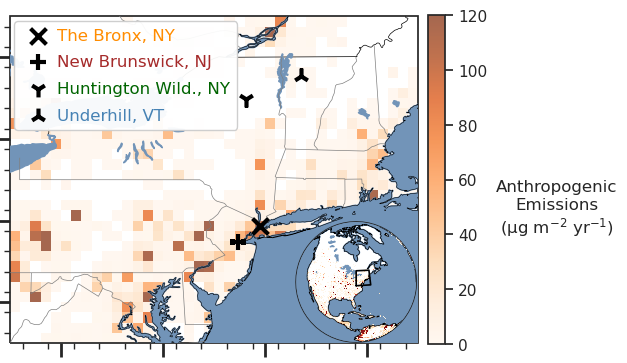

In [208]:
if figure1 == True:
    std_ticks = xr.open_dataset(path+'GC_output/STND/GEOSChem.MercuryEmis.20190101_0000z.nc4')
    nested_ticks = xr.open_dataset(path+'GC_output/NEST/GEOSChem.MercuryEmis.20190101_0000z.nc4')

    proj = ccrs.PlateCarree()

    #getting lat/lon for ticks
    s_lat = std_ticks.lat_bnds.values[:,0]
    s_lon = std_ticks.lon_bnds.values[:,0]
    n_lat = nested_ticks.lat_bnds.values[:,0] #base_n.lat_bnds.values[:,0]
    n_lon = nested_ticks.lon_bnds.values[:,0] #base_n.lon_bnds.values[:,0]

    #reading in 2015 anthropogenic emissions from GMA, converting from kg m-2 s-1 to µg m-2 yr-1
    gma = xr.open_dataset(path+'GMA/GMA_emissions_Hg.0.25x0.25.2015.nc')

    for i in list(gma):
        if i == list(gma)[0]:
            gma['emi_tot'] = gma[i]
        else:
            gma['emi_tot'] = gma['emi_tot']+gma[i]

    gma = gma['emi_tot'].isel(time=0)
    gma = f.zerofilter(gma,thresh=1e-17)
    gma = gma*60*60*24*365*1e9


    # --- plotting figure 1 below ---
    land = 'white'
    water = '#7294b8'
    boarder = 'black'

    lonmin = -80
    lonmax = -70
    latmin = 38
    latmax = 46

    x = [lonmin,lonmin,lonmax,lonmax,lonmin]
    y = [latmin,latmax,latmax,latmin,latmin]

    states_provinces = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='50m',
            facecolor='none')

    fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.PlateCarree()})

    g = ax.pcolormesh(gma.lon,gma.lat,gma,vmin=0,vmax=120,cmap='Oranges',alpha=0.7) #'Oranges'#OrRd

    ax.add_feature(cfeature.LAND,color=land)
    ax.add_feature(cfeature.LAKES,color=water,zorder=10)
    ax.add_feature(cfeature.OCEAN,color=water,zorder=10)
    ax.add_feature(cfeature.COASTLINE,color=boarder,linewidth=0.4,zorder=10)
    ax.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
    ax.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='gray')

    #adding ticks
    ax.set_xticks(s_lon, crs=proj)
    ax.set_yticks(s_lat,crs=proj)
    ax.set_xticks(n_lon, crs=proj,minor=True)
    ax.set_yticks(n_lat,crs=proj,minor=True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.xaxis.set_tick_params(width=2,length=10)
    ax.yaxis.set_tick_params(width=2,length=10)

    ax.set_extent([lonmin,lonmax,latmin,latmax])

    ax.scatter(bronx[0],bronx[1],marker='x',c='black',s=130,zorder=10,linewidth=3,label='The Bronx, NY')
    ax.scatter(nbrunswick[0],nbrunswick[1],marker='+',c='black',s=130,zorder=10,linewidth=3,label='New Brunswick, NJ')
    ax.scatter(huntington[0],huntington[1],marker='1',c='black',s=130,zorder=10,linewidth=3,label='Huntington Wild., NY')
    ax.scatter(underhill[0],underhill[1],marker='2',c='black',s=130,zorder=10,linewidth=3,label='Underhill, VT')

    cbar = plt.colorbar(g,shrink=0.74,pad=0.02)
    cbar.ax.set_ylabel('Anthropogenic\nEmissions\n(μg m$^{-2}$ yr$^{-1}$)',rotation=0,labelpad=50)

    ax.legend(bbox_to_anchor=(-0.01, 1.01), 
              loc='upper left',
              fontsize=12,
              framealpha=0.95,
              handletextpad=0.18,
              labelspacing=0.7,
              labelcolor=['darkorange', 'brown','darkgreen','steelblue']).set_zorder(11)

    ax1 = fig.add_axes([0.444, 0.162, 0.25, 0.25], projection=ccrs.NearsidePerspective(central_longitude=-80, central_latitude=40,satellite_height=5785831))
    ax1.add_feature(cfeature.LAND,color=land)
    ax1.add_feature(cfeature.LAKES,color=water,zorder=10)
    ax1.add_feature(cfeature.OCEAN,color=water,zorder=10)
    ax1.pcolormesh(gma.lon,gma.lat,gma,vmin=0,vmax=100,cmap='OrRd',alpha=0.9,transform=ccrs.PlateCarree(),zorder=10) #'Oranges'
    ax1.add_feature(cfeature.COASTLINE,color=boarder,zorder=11,linewidth=0.5)
    ax1.plot(x, y, transform=ccrs.PlateCarree(),zorder=12,c='black',linewidth=1.2)

    plt.tight_layout()
    plt.savefig(figpath+'Fig1_EST.png',dpi=dpi,transparent=True)#+figformat,dpi=dpi,transparent=True)

/tmp/ipykernel_907/170647286.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


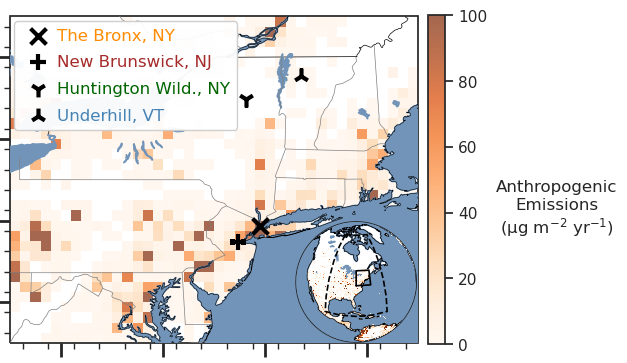

In [209]:
if figure1 == True:
    proj = ccrs.PlateCarree()

    #getting lat/lon for ticks
    s_lat = std_ticks.lat_bnds.values[:,0]
    s_lon = std_ticks.lon_bnds.values[:,0]
    n_lat = nested_ticks.lat_bnds.values[:,0] #base_n.lat_bnds.values[:,0]
    n_lon = nested_ticks.lon_bnds.values[:,0] #base_n.lon_bnds.values[:,0]

    # --- plotting figure 1 below ---
    land = 'white'
    water = '#7294b8'
    boarder = 'black'

    lonmin = -80
    lonmax = -70
    latmin = 38
    latmax = 46

    x = [lonmin,lonmin,lonmax,lonmax,lonmin]
    y = [latmin,latmax,latmax,latmin,latmin]

    #Nested domain
    x_nest = [-100,-90,-80,-70,-60,-60,-60,-60,-60,-60,-70,-80,-90,-100,-100,-100,-100,-100,-100]
    y_nest = [70,70,70,70,70,60,50,40,30,20,20,20,20,20,30,40,50,60,70]
    xy = list(zip(x_nest, y_nest))
    
    states_provinces = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='50m',
            facecolor='none')

    fig, ax = plt.subplots(1, 1, subplot_kw={'projection': ccrs.PlateCarree()})

    g = ax.pcolormesh(gma.lon,gma.lat,gma,vmin=0,vmax=100,cmap='Oranges',alpha=0.7) #'Oranges'

    ax.add_feature(cfeature.LAND,color=land)
    ax.add_feature(cfeature.LAKES,color=water,zorder=10)
    ax.add_feature(cfeature.OCEAN,color=water,zorder=10)
    ax.add_feature(cfeature.COASTLINE,color=boarder,linewidth=0.4,zorder=10)
    ax.add_feature(cfeature.BORDERS,color=boarder,linewidth=0.5)
    ax.add_feature(states_provinces,linewidth=0.5,zorder=10,edgecolor='gray')

    #adding ticks
    ax.set_xticks(s_lon, crs=proj)
    ax.set_yticks(s_lat,crs=proj)
    ax.set_xticks(n_lon, crs=proj,minor=True)
    ax.set_yticks(n_lat,crs=proj,minor=True)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.xaxis.set_tick_params(width=2,length=10)
    ax.yaxis.set_tick_params(width=2,length=10)

    ax.set_extent([lonmin,lonmax,latmin,latmax])

    ax.scatter(bronx[0],bronx[1],marker='x',c='black',s=130,zorder=10,linewidth=3,label='The Bronx, NY')
    ax.scatter(nbrunswick[0],nbrunswick[1],marker='+',c='black',s=130,zorder=10,linewidth=3,label='New Brunswick, NJ')
    ax.scatter(huntington[0],huntington[1],marker='1',c='black',s=130,zorder=10,linewidth=3,label='Huntington Wild., NY')
    ax.scatter(underhill[0],underhill[1],marker='2',c='black',s=130,zorder=10,linewidth=3,label='Underhill, VT')

    cbar = plt.colorbar(g,shrink=0.74,pad=0.02)
    cbar.ax.set_ylabel('Anthropogenic\nEmissions\n(μg m$^{-2}$ yr$^{-1}$)',rotation=0,labelpad=50)

    ax.legend(bbox_to_anchor=(-0.01, 1.01), 
              loc='upper left',
              fontsize=12,
              framealpha=0.95,
              handletextpad=0.18,
              labelspacing=0.7,
              labelcolor=['darkorange', 'brown','darkgreen','steelblue']).set_zorder(11)

    ax1 = fig.add_axes([0.444, 0.162, 0.25, 0.25], projection=ccrs.NearsidePerspective(central_longitude=-80, central_latitude=40,satellite_height=5785831))
    ax1.add_feature(cfeature.LAND,color=land)
    ax1.add_feature(cfeature.LAKES,color=water,zorder=10)
    ax1.add_feature(cfeature.OCEAN,color=water,zorder=10)
    ax1.pcolormesh(gma.lon,gma.lat,gma,vmin=0,vmax=100,cmap='Oranges',alpha=0.9,transform=ccrs.PlateCarree(),zorder=10) #'Oranges'
    ax1.add_feature(cfeature.COASTLINE,color=boarder,zorder=11,linewidth=0.5)
    ax1.plot(x, y, transform=ccrs.PlateCarree(),zorder=12,c='black',linewidth=1.2)
    ax1.add_patch(mpatches.Polygon(xy,facecolor='none', edgecolor='black',linewidth=1.2,linestyle='--',
                                    transform=ccrs.PlateCarree(),zorder=15))

    plt.tight_layout()
    plt.savefig(figpath+'Fig1_EST_wNest.png',dpi=dpi,transparent=True)#+figformat,dpi=dpi,transparent=True)

In [210]:
if figure2_5 == True:
    month = 6
    file = 'GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'
    #reading in GEOS-Chem datasets (s = std res, n = nested res)
    base_s = xr.open_mfdataset(path+'/GC_output/STND/'+file)
    base_n = xr.open_mfdataset(path+'/GC_output/NEST/'+file)

    
    EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
    BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
    MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

    #processing pbl data for nearby airports
    pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                            'BDL_pblh':BDL_df['pblh'],
                            'MHT_pblh':MHT_df['pblh'],
                            'EWR_windmag':EWR_df['windmag'],
                            'BDL_windmag':BDL_df['windmag'],
                            'MHT_windmag':MHT_df['windmag']})

    pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
    pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

    pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
    pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()

    ### Reading in NADP data ###
    Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
    Amnet['collStart'] = pd.to_datetime(Amnet['collStart'])
    Amnet['collEnd'] = pd.to_datetime(Amnet['collEnd'])
    Amnet = Amnet.set_index('collStart')

    #subsetting sites of interest
    start = '2011-01-01'#'2014-01-01'
    end = '2020-01-01'

    Amnet = Amnet[Amnet.index>start]
    Amnet = Amnet[Amnet.index<end]
    Amnet_all = Amnet.copy()
    Amnet = Amnet[Amnet.index.month==month]
    Amnet['hour'] = Amnet.index.hour 

    #extracting monthly diel cycles for all interesting sites
    NJ54 = Amnet[Amnet['SiteID']=='NJ54'].groupby('hour').mean()
    NJ30 = Amnet[Amnet['SiteID']=='NJ30'].groupby('hour').mean()
    NY06 = Amnet[Amnet['SiteID']=='NY06'].groupby('hour').mean()
    NY20 = Amnet[Amnet['SiteID']=='NY20'].groupby('hour').mean()
    VT99 = Amnet[Amnet['SiteID']=='VT99'].groupby('hour').mean()
    MD08 = Amnet[Amnet['SiteID']=='MD08'].groupby('hour').mean()
    MD99 = Amnet[Amnet['SiteID']=='MD98'].groupby('hour').mean()
    NJ05 = Amnet[Amnet['SiteID']=='NJ05'].groupby('hour').mean()

    NJ30_h = Amnet_all[Amnet_all['SiteID']=='NJ30']
    NY06_h = Amnet_all[Amnet_all['SiteID']=='NY06']
    NY20_h = Amnet_all[Amnet_all['SiteID']=='NY20']
    VT99_h = Amnet_all[Amnet_all['SiteID']=='VT99']

    # --- making df with key observations ---
    measurements = pd.merge(NY20['GEM'],NY06['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM_x':'NY20','GEM_y':'NY06'})
    measurements = pd.merge(measurements,NJ30['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM':'NJ30'})
    measurements = pd.merge(measurements,VT99['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM':'VT99'})
    measurements['urban'] = ((measurements['NY06'].interpolate()+measurements['NJ30'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
    measurements['rural'] = ((measurements['NY20'].interpolate()+measurements['VT99'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()

    # --- Read in GEOS-Chem diel cycles (June) ---

    base_st = f.HgConversion(base_s['SpeciesConcVV_Hg0'].isel(lev=0).shift(time=shift).groupby('time.hour').mean())
    base_nt = f.HgConversion(base_n['SpeciesConcVV_Hg0'].isel(lev=0).shift(time=shift).groupby('time.hour').mean())

    bronx_st = base_st.sel(lat=bronx[1],lon=bronx[0],method='nearest').to_dataframe()
    bronx_nt = base_nt.sel(lat=bronx[1],lon=bronx[0],method='nearest').to_dataframe()

    nbrunswick_st = base_st.sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').to_dataframe()
    nbrunswick_nt = base_nt.sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').to_dataframe()

    underhill_st = base_st.sel(lat=underhill[1],lon=underhill[0],method='nearest').to_dataframe()
    underhill_nt = base_nt.sel(lat=underhill[1],lon=underhill[0],method='nearest').to_dataframe()

    huntington_st = base_st.sel(lat=huntington[1],lon=huntington[0],method='nearest').to_dataframe()
    huntington_nt = base_nt.sel(lat=huntington[1],lon=huntington[0],method='nearest').to_dataframe()


    # --- calculating hypothetical box model scenarios to demonstrate its utility ---

    uw = 1.7
    ft = 1.1
    fluxes = np.linspace(-70,70,40)

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements,var='urban',option=option)
    opt_urban_71 = f.box_model(flxopt,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements,var='rural',option=option)
    opt_rural_71 = f.box_model(flxopt,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    uw = 1.1
    ft = 1.7

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements,var='urban',option=option)
    opt_urban_17 = f.box_model(flxopt,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements,var='rural',option=option)
    opt_rural_17 = f.box_model(flxopt,pbl,measurements,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    # --- now, repeating the same exercise for december data ---

    month = 12

    file = 'GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'
    #reading in GEOS-Chem datasets (s = std res, n = nested res)
    base_s = xr.open_mfdataset(path+'/GC_output/STND/'+file)
    base_n = xr.open_mfdataset(path+'/GC_output/NEST/'+file)

    file_d = 'GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'#'/OutputDir/GEOSChem.SpeciesConcHF.20190[6-8]01_0000z.nc4'

    base_s_d = xr.open_mfdataset(path+'/GC_output/STND/'+file)
    base_n_d = xr.open_mfdataset(path+'/GC_output/NEST/'+file)

    proj = ccrs.PlateCarree()

    EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
    BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
    MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

    #processing pbl data for nearby airports
    pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                            'BDL_pblh':BDL_df['pblh'],
                            'MHT_pblh':MHT_df['pblh'],
                            'EWR_windmag':EWR_df['windmag'],
                            'BDL_windmag':BDL_df['windmag'],
                            'MHT_windmag':MHT_df['windmag']})

    pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
    pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

    pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
    pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()

    Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
    Amnet['collStart'] = pd.to_datetime(Amnet['collStart'])
    Amnet['collEnd'] = pd.to_datetime(Amnet['collEnd'])
    Amnet = Amnet.set_index('collStart')

    #subsetting sites of interest
    start = '2014-01-01'
    end = '2020-01-01'

    Amnet = Amnet[Amnet.index>start]
    Amnet = Amnet[Amnet.index<end]
    Amnet_all = Amnet.copy()
    Amnet = Amnet[Amnet.index.month==month]
    Amnet['hour'] = Amnet.index.hour 

    NJ54_d = Amnet[Amnet['SiteID']=='NJ54'].groupby('hour').mean()
    NJ30_d = Amnet[Amnet['SiteID']=='NJ30'].groupby('hour').mean()
    NY06_d = Amnet[Amnet['SiteID']=='NY06'].groupby('hour').mean()
    NY20_d = Amnet[Amnet['SiteID']=='NY20'].groupby('hour').mean()
    VT99_d = Amnet[Amnet['SiteID']=='VT99'].groupby('hour').mean()
    MD08_d = Amnet[Amnet['SiteID']=='MD08'].groupby('hour').mean()
    MD99_d = Amnet[Amnet['SiteID']=='MD98'].groupby('hour').mean()
    NJ05_d = Amnet[Amnet['SiteID']=='NJ05'].groupby('hour').mean()

    NJ30_h_d = Amnet_all[Amnet_all['SiteID']=='NJ30']
    NY06_h_d = Amnet_all[Amnet_all['SiteID']=='NY06']
    NY20_h_d = Amnet_all[Amnet_all['SiteID']=='NY20']
    VT99_h_d = Amnet_all[Amnet_all['SiteID']=='VT99']

    measurements_d = pd.merge(NY20_d['GEM'],NY06_d['GEM'],left_index=True,right_index=True)
    measurements_d = measurements_d.rename(columns={'GEM_x':'NY20','GEM_y':'NY06'})
    measurements_d = pd.merge(measurements_d,NJ30_d['GEM'],left_index=True,right_index=True)
    measurements_d = measurements_d.rename(columns={'GEM':'NJ30'})
    measurements_d = pd.merge(measurements_d,VT99_d['GEM'],left_index=True,right_index=True)
    measurements_d = measurements_d.rename(columns={'GEM':'VT99'})
    measurements_d['urban'] = ((measurements_d['NY06'].interpolate()+measurements_d['NJ30'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
    measurements_d['rural'] = ((measurements_d['NY20'].interpolate()+measurements_d['VT99'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()

    # --- Read in GEOS-Chem diel cycles (December) ---

    base_st_d = f.HgConversion(base_s_d['SpeciesConcVV_Hg0'].isel(lev=0).shift(time=shift).groupby('time.hour').mean())
    base_nt_d = f.HgConversion(base_n_d['SpeciesConcVV_Hg0'].isel(lev=0).shift(time=shift).groupby('time.hour').mean())

    bronx_st_d = base_st_d.sel(lat=bronx[1],lon=bronx[0],method='nearest').to_dataframe()
    bronx_nt_d = base_nt_d.sel(lat=bronx[1],lon=bronx[0],method='nearest').to_dataframe()

    nbrunswick_st_d = base_st_d.sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').to_dataframe()
    nbrunswick_nt_d = base_nt_d.sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').to_dataframe()

    underhill_st_d = base_st_d.sel(lat=underhill[1],lon=underhill[0],method='nearest').to_dataframe()
    underhill_nt_d = base_nt_d.sel(lat=underhill[1],lon=underhill[0],method='nearest').to_dataframe()

    huntington_st_d = base_st_d.sel(lat=huntington[1],lon=huntington[0],method='nearest').to_dataframe()
    huntington_nt_d = base_nt_d.sel(lat=huntington[1],lon=huntington[0],method='nearest').to_dataframe()

    # --- calculating hypothetical box model scenarios to demonstrate its utility (here, using december met and obs instead) ---

    uw = 1.7
    ft = 1.1
    fluxes = np.linspace(-70,70,40)

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements_d,var='urban',option=option)
    opt_urban_71_d = f.box_model(flxopt,pbl,measurements_d,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements_d,var='rural',option=option)
    opt_rural_71_d = f.box_model(flxopt,pbl,measurements_d,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    uw = 1.1
    ft = 1.7

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements_d,var='urban',option=option)
    opt_urban_17_d = f.box_model(flxopt,pbl,measurements_d,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']

    flxopt,prb = f.optimal_flux(pbl,uw,ft,fluxes,measurements_d,var='rural',option=option)
    opt_rural_17_d = f.box_model(flxopt,pbl,measurements_d,upw_conc=uw,hg_ft=ft,groupby=True)['hg_box']


/tmp/ipykernel_907/113485820.py:28: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instea

/tmp/ipykernel_907/996139423.py:153: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout() # Adjust subplot parameters for a tight layout


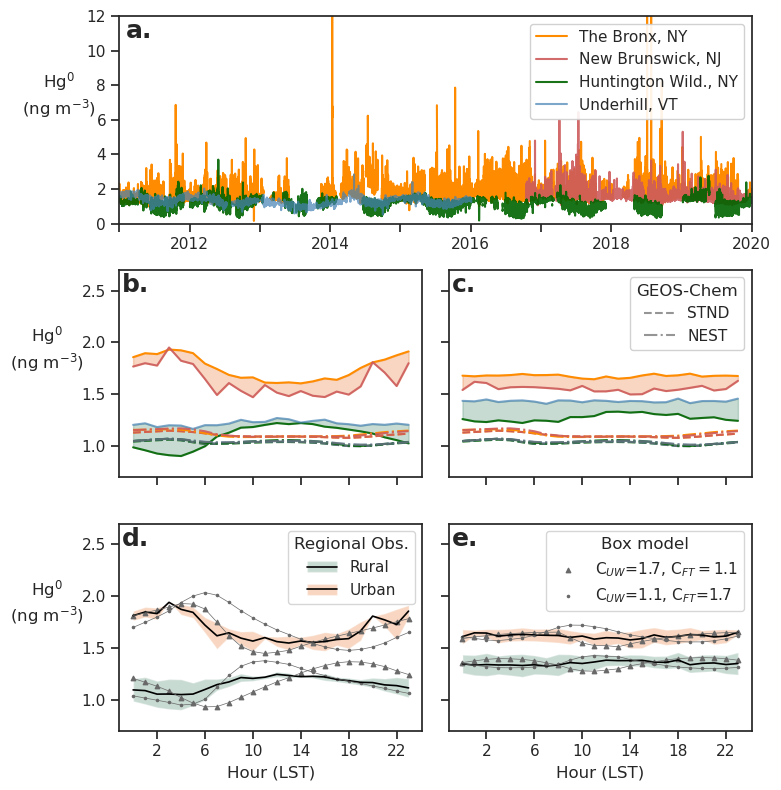

In [211]:
if figure2_5 == True:
    # -------------------------------------
    # --- Figure 2 plotting/compilation ---
    # -------------------------------------

    fig, ax_dict = plt.subplot_mosaic([['top_panel', 'top_panel'],
                                       ['middle_left', 'middle_right'],
                                       ['bottom_left', 'bottom_right']],
                                      figsize=(8, 8),layout='constrained')

    # Access the axes by their names
    ax_top = ax_dict['top_panel']
    ax_middle_left = ax_dict['middle_left']
    ax_middle_right = ax_dict['middle_right']
    ax_bottom_left = ax_dict['bottom_left']
    ax_bottom_right = ax_dict['bottom_right']


    ax_top.plot(NY06_h.index,NY06_h['GEM'],c='darkorange',label='The Bronx, NY')
    ax_top.plot(NJ30_h.index,NJ30_h['GEM'],c='indianred',alpha=0.9,label='New Brunswick, NJ')
    ax_top.plot(NY20_h.index,NY20_h['GEM'],c='darkgreen',alpha=0.9,label='Huntington Wild., NY')
    ax_top.plot(VT99_h.index,VT99_h['GEM'],c='steelblue',alpha=0.7,label='Underhill, VT')

    ax_top.set_ylim(0,8)

    ax_middle_left.plot(NY06.index,NY06['GEM'],c='darkorange')
    ax_middle_left.plot(NJ30.index,NJ30['GEM'],c='indianred',alpha=0.9)
    ax_middle_left.plot(NY20.index,NY20['GEM'],c='darkgreen',alpha=0.9)
    ax_middle_left.plot(VT99.index,VT99['GEM'],c='steelblue',alpha=0.7)

    #adding fill between
    ax_middle_left.fill_between(NY06.index, NY06['GEM'], NJ30['GEM'],color='#e87832',alpha=0.3)
    ax_middle_left.fill_between(NY20.index, NY20['GEM'], VT99['GEM'],color='#4a8a6f',alpha=0.3)

    ax_middle_left.plot(bronx_st.index,bronx_st['SpeciesConcVV_Hg0'],c='darkorange',linestyle='--')
    ax_middle_left.plot(nbrunswick_st.index,nbrunswick_st['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='--')
    ax_middle_left.plot(huntington_st.index,huntington_st['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='--')
    ax_middle_left.plot(underhill_st.index,underhill_st['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='--')
    ax_middle_left.plot(underhill_st.index,underhill_st['SpeciesConcVV_Hg0'],c='dimgray',label='STND',alpha=0.7,linestyle='--')

    ax_middle_left.plot(bronx_nt.index,bronx_nt['SpeciesConcVV_Hg0'],c='darkorange',linestyle='-.')
    ax_middle_left.plot(nbrunswick_nt.index,nbrunswick_nt['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='-.')
    ax_middle_left.plot(huntington_nt.index,huntington_nt['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='-.')
    ax_middle_left.plot(underhill_nt.index,underhill_nt['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='-.')
    ax_middle_left.plot(underhill_nt.index,underhill_nt['SpeciesConcVV_Hg0'],c='dimgray',label='NEST',alpha=0.7,linestyle='-.')

    #december obs
    ax_middle_right.plot(NY06_d.index,NY06_d['GEM'],c='darkorange')
    ax_middle_right.plot(NJ30_d.index,NJ30_d['GEM'],c='indianred',alpha=0.9)
    ax_middle_right.plot(NY20_d.index,NY20_d['GEM'],c='darkgreen',alpha=0.9)
    ax_middle_right.plot(VT99_d.index,VT99_d['GEM'],c='steelblue',alpha=0.7)

    #adding fill between
    ax_middle_right.fill_between(NY06_d.index, NY06_d['GEM'], NJ30_d['GEM'],color='#e87832',alpha=0.3)
    ax_middle_right.fill_between(NY20_d.index, NY20_d['GEM'], VT99_d['GEM'],color='#4a8a6f',alpha=0.3)

    ax_middle_right.plot(bronx_st_d.index,bronx_st_d['SpeciesConcVV_Hg0'],c='darkorange',linestyle='--')
    ax_middle_right.plot(nbrunswick_st_d.index,nbrunswick_st_d['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='--')
    ax_middle_right.plot(huntington_st_d.index,huntington_st_d['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='--')
    ax_middle_right.plot(underhill_st_d.index,underhill_st_d['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='--')
    ax_middle_right.plot(underhill_st_d.index,underhill_st_d['SpeciesConcVV_Hg0'],c='dimgray',label='STND',alpha=0.7,linestyle='--')

    ax_middle_right.plot(bronx_nt_d.index,bronx_nt_d['SpeciesConcVV_Hg0'],c='darkorange',linestyle='-.')
    ax_middle_right.plot(nbrunswick_nt_d.index,nbrunswick_nt_d['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='-.')
    ax_middle_right.plot(huntington_nt_d.index,huntington_nt_d['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='-.')
    ax_middle_right.plot(underhill_nt_d.index,underhill_nt_d['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='-.')
    ax_middle_right.plot(underhill_nt_d.index,underhill_nt_d['SpeciesConcVV_Hg0'],c='dimgray',label='NEST',alpha=0.7,linestyle='-.')

    #now box model results
    ufill = ax_bottom_left.fill_between(NY06.index, NY06['GEM'], NJ30['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    rfill = ax_bottom_left.fill_between(NY20.index, NY20['GEM'], VT99['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)

    uline, = ax_bottom_left.plot(NY06.index,(NY06['GEM']+NJ30['GEM'])/2,c='black',linewidth=1.2)
    rline, = ax_bottom_left.plot(NY20.index,(NY20['GEM']+VT99['GEM'])/2,c='black',linewidth=1.2)
    ax_bottom_left.scatter(opt_urban_71.index,opt_urban_71,marker='^',c='dimgray',s=10,label='C$_{UW}$=1.7, C$_{FT}=$1.1')
    ax_bottom_left.plot(opt_urban_71,c='dimgray',linewidth=0.5)
    ax_bottom_left.scatter(opt_urban_71.index,opt_rural_71,marker='^',c='dimgray',s=10)
    ax_bottom_left.plot(opt_rural_71,c='dimgray',linewidth=0.5)
    ax_bottom_left.scatter(opt_urban_71.index,opt_urban_17,marker='.',c='dimgray',s=10,label='C$_{UW}$=1.1, C$_{FT}$=1.7')
    ax_bottom_left.plot(opt_urban_17,c='dimgray',linewidth=0.5)
    ax_bottom_left.scatter(opt_urban_71.index,opt_rural_17,marker='.',c='dimgray',s=10)
    ax_bottom_left.plot(opt_rural_17,c='dimgray',linewidth=0.5)

    ax_bottom_right.fill_between(NY06_d.index, NY06_d['GEM'], NJ30_d['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    ax_bottom_right.fill_between(NY20_d.index, NY20_d['GEM'], VT99_d['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)

    ax_bottom_right.plot(NY06_d.index,(NY06_d['GEM']+NJ30_d['GEM'])/2,c='black',linewidth=1.2)
    ax_bottom_right.plot(NY20_d.index,(NY20_d['GEM']+VT99_d['GEM'])/2,c='black',linewidth=1.2)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_urban_71_d,marker='^',c='dimgray',s=10,label='C$_{UW}$=1.7, C$_{FT}=$1.1')
    ax_bottom_right.plot(opt_urban_71_d,c='dimgray',linewidth=0.5)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_rural_71_d,marker='^',c='dimgray',s=10)
    ax_bottom_right.plot(opt_rural_71_d,c='dimgray',linewidth=0.5)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_urban_17_d,marker='.',c='dimgray',s=10,label='C$_{UW}$=1.1, C$_{FT}$=1.7')
    ax_bottom_right.plot(opt_urban_17_d,c='dimgray',linewidth=0.5)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_rural_17_d,marker='.',c='dimgray',s=10)
    ax_bottom_right.plot(opt_rural_17_d,c='dimgray',linewidth=0.5)

    #setting aesthetics

    #setting xticks
    ax_top.set_xlim(pd.to_datetime('2011'),pd.to_datetime('2020'))
    ax_top.set_xticks(['2011','2012','2013','2014','2015','2016','2017','2018','2019','2020'])
    ax_top.set_xticklabels(['','2012','','2014','','2016','','2018','','2020'])

    ax_middle_left.set_xticks([2,6,10,14,18,22])
    ax_bottom_left.set_xticks([2,6,10,14,18,22])
    ax_middle_right.set_xticks([2,6,10,14,18,22])
    ax_bottom_right.set_xticks([2,6,10,14,18,22])
    ax_middle_left.axes.xaxis.set_ticklabels([])
    ax_middle_right.axes.xaxis.set_ticklabels([])

    #setting yticks
    ax_middle_left.set_yticks([1,1.5,2,2.5])
    ax_bottom_left.set_yticks([1,1.5,2,2.5])
    ax_middle_right.set_yticks([1,1.5,2,2.5])
    ax_bottom_right.set_yticks([1,1.5,2,2.5])


    #ylabels
    ax_top.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=20)
    ax_middle_left.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=25)
    ax_bottom_left.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=25)

    ax_middle_right.axes.yaxis.set_ticklabels([])
    ax_bottom_right.axes.yaxis.set_ticklabels([])

    #xlabels
    ax_bottom_left.set_xlabel('Hour (LST)')
    ax_bottom_right.set_xlabel('Hour (LST)')

    #legends
    tl = ax_top.legend(loc='upper right',framealpha=0.9)
    mrl = ax_middle_right.legend(loc='upper right',title='GEOS-Chem',framealpha=0.9) #,title='GEOS-Chem Res.'
    brl = ax_bottom_right.legend(loc='upper right',title='Box model')#title='Box model (C$_{UW}$, C$_{FT}$)' #title for legend
    bll = ax_bottom_left.legend([(rfill, rline),(ufill, uline)], ['Rural','Urban'],loc='upper right',title='Regional Obs.')
    
    #y limits
    ax_top.set_ylim(0,12)
    ax_middle_left.set_ylim(0.7,2.7)
    ax_middle_right.set_ylim(0.7,2.7)
    ax_bottom_left.set_ylim(0.7,2.7)
    ax_bottom_right.set_ylim(0.7,2.7)

    #add some axis labels
    ax_top.annotate('a.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_middle_left.annotate('b.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_middle_right.annotate('c.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_bottom_left.annotate('d.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_bottom_right.annotate('e.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')

    
    #final export, display
    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.savefig(figpath+'Fig2_EST.'+figformat,dpi=dpi,transparent=True)

    # --- Figure 2 complete ---

/tmp/ipykernel_907/2827953616.py:153: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout() # Adjust subplot parameters for a tight layout


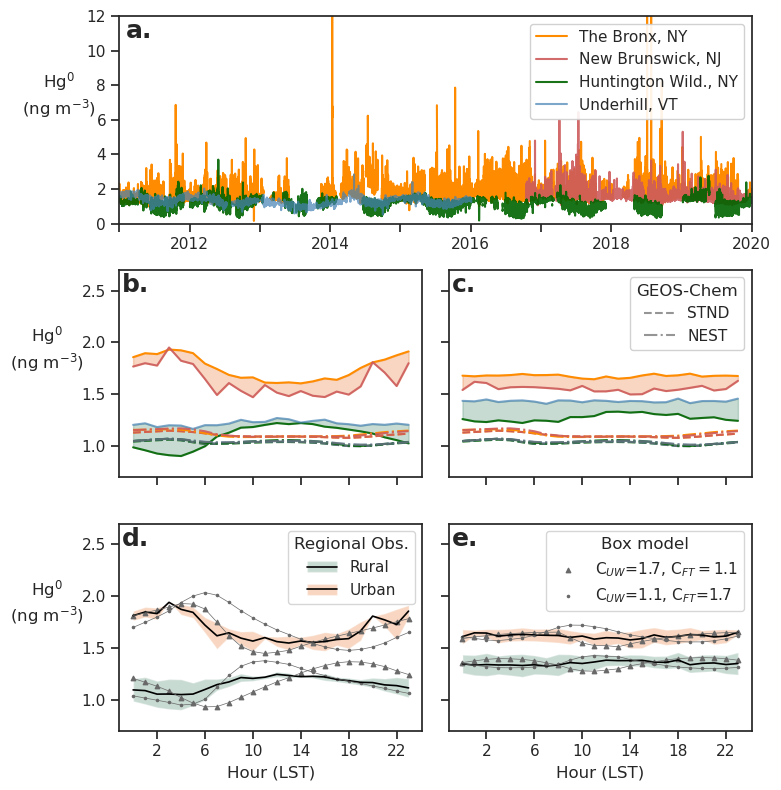

In [212]:
if figure2_5 == True:
    # -------------------------------------
    # --- Figure 2 plotting/compilation ---
    # -------------------------------------

    fig, ax_dict = plt.subplot_mosaic([['top_panel', 'top_panel'],
                                       ['middle_left', 'middle_right'],
                                       ['bottom_left', 'bottom_right']],
                                      figsize=(8, 8),layout='constrained')

    # Access the axes by their names
    ax_top = ax_dict['top_panel']
    ax_middle_left = ax_dict['middle_left']
    ax_middle_right = ax_dict['middle_right']
    ax_bottom_left = ax_dict['bottom_left']
    ax_bottom_right = ax_dict['bottom_right']


    ax_top.plot(NY06_h.index,NY06_h['GEM'],c='darkorange',label='The Bronx, NY')
    ax_top.plot(NJ30_h.index,NJ30_h['GEM'],c='indianred',alpha=0.9,label='New Brunswick, NJ')
    ax_top.plot(NY20_h.index,NY20_h['GEM'],c='darkgreen',alpha=0.9,label='Huntington Wild., NY')
    ax_top.plot(VT99_h.index,VT99_h['GEM'],c='steelblue',alpha=0.7,label='Underhill, VT')

    ax_top.set_ylim(0,8)

    ax_middle_left.plot(NY06.index,NY06['GEM'],c='darkorange')
    ax_middle_left.plot(NJ30.index,NJ30['GEM'],c='indianred',alpha=0.9)
    ax_middle_left.plot(NY20.index,NY20['GEM'],c='darkgreen',alpha=0.9)
    ax_middle_left.plot(VT99.index,VT99['GEM'],c='steelblue',alpha=0.7)

    #adding fill between
    ax_middle_left.fill_between(NY06.index, NY06['GEM'], NJ30['GEM'],color='#e87832',alpha=0.3)
    ax_middle_left.fill_between(NY20.index, NY20['GEM'], VT99['GEM'],color='#4a8a6f',alpha=0.3)

    ax_middle_left.plot(bronx_st.index,bronx_st['SpeciesConcVV_Hg0'],c='darkorange',linestyle='--')
    ax_middle_left.plot(nbrunswick_st.index,nbrunswick_st['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='--')
    ax_middle_left.plot(huntington_st.index,huntington_st['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='--')
    ax_middle_left.plot(underhill_st.index,underhill_st['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='--')
    ax_middle_left.plot(underhill_st.index,underhill_st['SpeciesConcVV_Hg0'],c='dimgray',label='STND',alpha=0.7,linestyle='--')

    ax_middle_left.plot(bronx_nt.index,bronx_nt['SpeciesConcVV_Hg0'],c='darkorange',linestyle='-.')
    ax_middle_left.plot(nbrunswick_nt.index,nbrunswick_nt['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='-.')
    ax_middle_left.plot(huntington_nt.index,huntington_nt['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='-.')
    ax_middle_left.plot(underhill_nt.index,underhill_nt['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='-.')
    ax_middle_left.plot(underhill_nt.index,underhill_nt['SpeciesConcVV_Hg0'],c='dimgray',label='NEST',alpha=0.7,linestyle='-.')

    #december obs
    ax_middle_right.plot(NY06_d.index,NY06_d['GEM'],c='darkorange')
    ax_middle_right.plot(NJ30_d.index,NJ30_d['GEM'],c='indianred',alpha=0.9)
    ax_middle_right.plot(NY20_d.index,NY20_d['GEM'],c='darkgreen',alpha=0.9)
    ax_middle_right.plot(VT99_d.index,VT99_d['GEM'],c='steelblue',alpha=0.7)

    #adding fill between
    ax_middle_right.fill_between(NY06_d.index, NY06_d['GEM'], NJ30_d['GEM'],color='#e87832',alpha=0.3)
    ax_middle_right.fill_between(NY20_d.index, NY20_d['GEM'], VT99_d['GEM'],color='#4a8a6f',alpha=0.3)

    ax_middle_right.plot(bronx_st_d.index,bronx_st_d['SpeciesConcVV_Hg0'],c='darkorange',linestyle='--')
    ax_middle_right.plot(nbrunswick_st_d.index,nbrunswick_st_d['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='--')
    ax_middle_right.plot(huntington_st_d.index,huntington_st_d['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='--')
    ax_middle_right.plot(underhill_st_d.index,underhill_st_d['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='--')
    ax_middle_right.plot(underhill_st_d.index,underhill_st_d['SpeciesConcVV_Hg0'],c='dimgray',label='STND',alpha=0.7,linestyle='--')

    ax_middle_right.plot(bronx_nt_d.index,bronx_nt_d['SpeciesConcVV_Hg0'],c='darkorange',linestyle='-.')
    ax_middle_right.plot(nbrunswick_nt_d.index,nbrunswick_nt_d['SpeciesConcVV_Hg0'],c='indianred',alpha=0.9,linestyle='-.')
    ax_middle_right.plot(huntington_nt_d.index,huntington_nt_d['SpeciesConcVV_Hg0'],c='darkgreen',alpha=0.9,linestyle='-.')
    ax_middle_right.plot(underhill_nt_d.index,underhill_nt_d['SpeciesConcVV_Hg0'],c='steelblue',alpha=0.7,linestyle='-.')
    ax_middle_right.plot(underhill_nt_d.index,underhill_nt_d['SpeciesConcVV_Hg0'],c='dimgray',label='NEST',alpha=0.7,linestyle='-.')

    #now box model results
    ufill = ax_bottom_left.fill_between(NY06.index, NY06['GEM'], NJ30['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    rfill = ax_bottom_left.fill_between(NY20.index, NY20['GEM'], VT99['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)

    uline, = ax_bottom_left.plot(NY06.index,(NY06['GEM']+NJ30['GEM'])/2,c='black',linewidth=1.2)
    rline, = ax_bottom_left.plot(NY20.index,(NY20['GEM']+VT99['GEM'])/2,c='black',linewidth=1.2)
    ax_bottom_left.scatter(opt_urban_71.index,opt_urban_71,marker='^',c='dimgray',s=10,label='C$_{UW}$=1.7, C$_{FT}=$1.1')
    ax_bottom_left.plot(opt_urban_71,c='dimgray',linewidth=0.5)
    ax_bottom_left.scatter(opt_urban_71.index,opt_rural_71,marker='^',c='dimgray',s=10)
    ax_bottom_left.plot(opt_rural_71,c='dimgray',linewidth=0.5)
    ax_bottom_left.scatter(opt_urban_71.index,opt_urban_17,marker='.',c='dimgray',s=10,label='C$_{UW}$=1.1, C$_{FT}$=1.7')
    ax_bottom_left.plot(opt_urban_17,c='dimgray',linewidth=0.5)
    ax_bottom_left.scatter(opt_urban_71.index,opt_rural_17,marker='.',c='dimgray',s=10)
    ax_bottom_left.plot(opt_rural_17,c='dimgray',linewidth=0.5)

    ax_bottom_right.fill_between(NY06_d.index, NY06_d['GEM'], NJ30_d['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    ax_bottom_right.fill_between(NY20_d.index, NY20_d['GEM'], VT99_d['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)

    ax_bottom_right.plot(NY06_d.index,(NY06_d['GEM']+NJ30_d['GEM'])/2,c='black',linewidth=1.2)
    ax_bottom_right.plot(NY20_d.index,(NY20_d['GEM']+VT99_d['GEM'])/2,c='black',linewidth=1.2)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_urban_71_d,marker='^',c='dimgray',s=10,label='C$_{UW}$=1.7, C$_{FT}=$1.1')
    ax_bottom_right.plot(opt_urban_71_d,c='dimgray',linewidth=0.5)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_rural_71_d,marker='^',c='dimgray',s=10)
    ax_bottom_right.plot(opt_rural_71_d,c='dimgray',linewidth=0.5)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_urban_17_d,marker='.',c='dimgray',s=10,label='C$_{UW}$=1.1, C$_{FT}$=1.7')
    ax_bottom_right.plot(opt_urban_17_d,c='dimgray',linewidth=0.5)
    ax_bottom_right.scatter(opt_urban_71_d.index,opt_rural_17_d,marker='.',c='dimgray',s=10)
    ax_bottom_right.plot(opt_rural_17_d,c='dimgray',linewidth=0.5)

    #setting aesthetics

    #setting xticks
    ax_top.set_xlim(pd.to_datetime('2011'),pd.to_datetime('2020'))
    ax_top.set_xticks(['2011','2012','2013','2014','2015','2016','2017','2018','2019','2020'])
    ax_top.set_xticklabels(['','2012','','2014','','2016','','2018','','2020'])

    ax_middle_left.set_xticks([2,6,10,14,18,22])
    ax_bottom_left.set_xticks([2,6,10,14,18,22])
    ax_middle_right.set_xticks([2,6,10,14,18,22])
    ax_bottom_right.set_xticks([2,6,10,14,18,22])
    ax_middle_left.axes.xaxis.set_ticklabels([])
    ax_middle_right.axes.xaxis.set_ticklabels([])

    #setting yticks
    ax_middle_left.set_yticks([1,1.5,2,2.5])
    ax_bottom_left.set_yticks([1,1.5,2,2.5])
    ax_middle_right.set_yticks([1,1.5,2,2.5])
    ax_bottom_right.set_yticks([1,1.5,2,2.5])


    #ylabels
    ax_top.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=20)
    ax_middle_left.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=25)
    ax_bottom_left.set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=25)

    ax_middle_right.axes.yaxis.set_ticklabels([])
    ax_bottom_right.axes.yaxis.set_ticklabels([])

    #xlabels
    ax_bottom_left.set_xlabel('Hour (LST)')
    ax_bottom_right.set_xlabel('Hour (LST)')

    #legends
    tl = ax_top.legend(loc='upper right',framealpha=0.9)
    mrl = ax_middle_right.legend(loc='upper right',title='GEOS-Chem',framealpha=0.9) #,title='GEOS-Chem Res.'
    brl = ax_bottom_right.legend(loc='upper right',title='Box model')#title='Box model (C$_{UW}$, C$_{FT}$)' #title for legend
    bll = ax_bottom_left.legend([(rfill, rline),(ufill, uline)], ['Rural','Urban'],loc='upper right',title='Regional Obs.')
    
    #y limits
    ax_top.set_ylim(0,12)
    ax_middle_left.set_ylim(0.7,2.7)
    ax_middle_right.set_ylim(0.7,2.7)
    ax_bottom_left.set_ylim(0.7,2.7)
    ax_bottom_right.set_ylim(0.7,2.7)

    #add some axis labels
    ax_top.annotate('a.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_middle_left.annotate('b.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_middle_right.annotate('c.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_bottom_left.annotate('d.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax_bottom_right.annotate('e.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')

    
    #final export, display
    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.savefig(figpath+'Fig2_EST.png',dpi=dpi,transparent=True)

    # --- Figure 2 complete ---

In [161]:
#now calculating percentages for manuscript
if figure2_5 == True:
    #Percent difference of concentrations (how much larger is urban than rural) - JUNE
    u = (NY06['GEM']+NJ30['GEM'])/2
    r = (NY20['GEM']+VT99['GEM'])/2
    temp = (u-r)/u
    print('Rural Obs _% smaller than Urban (JUN): '+str(temp.min())+', '+str(temp.max()))
    #Percent difference of concentrations (how much larger is urban than rural) - DECEMBER
    u = (NY06_d['GEM']+NJ30_d['GEM'])/2
    r = (NY20_d['GEM']+VT99_d['GEM'])/2
    temp = (u-r)/u
    print('Rural Obs _% smaller than Urban (DEC): '+str(temp.min())+', '+str(temp.max()))
    #percent difference of midday concentrations at rural sites between JUNE and DECEMBER
    r_j = ((NY20['GEM']+VT99['GEM'])/2)
    r_d = ((NY20_d['GEM']+VT99_d['GEM'])/2)
    temp = (r_d-r_j)/r_d
    print('June Rural Obs _% smaller than Dec Rural Obs: '+str(temp.min())+', '+str(temp.max()))
    #percent difference of midday concentrations at urban sites between JUNE and DECEMBER
    r_j = ((NY06['GEM']+NJ30['GEM'])/2)
    r_d = ((NY06_d['GEM']+NJ30_d['GEM'])/2)
    temp = (r_d-r_j)/r_d
    print('June urban Obs _% smaller than Dec urban Obs: '+str(temp.min())+', '+str(temp.max()))


Rural Obs _% smaller than Urban (JUN): 0.20160591185893487, 0.4549469084134566
Rural Obs _% smaller than Urban (DEC): 0.12576869328478996, 0.18887557701907157
June Rural Obs _% smaller than Dec Rural Obs: 0.09840641692250364, 0.2132368513615269
June urban Obs _% smaller than Dec urban Obs: -0.2016999055016515, 0.03903424543793741


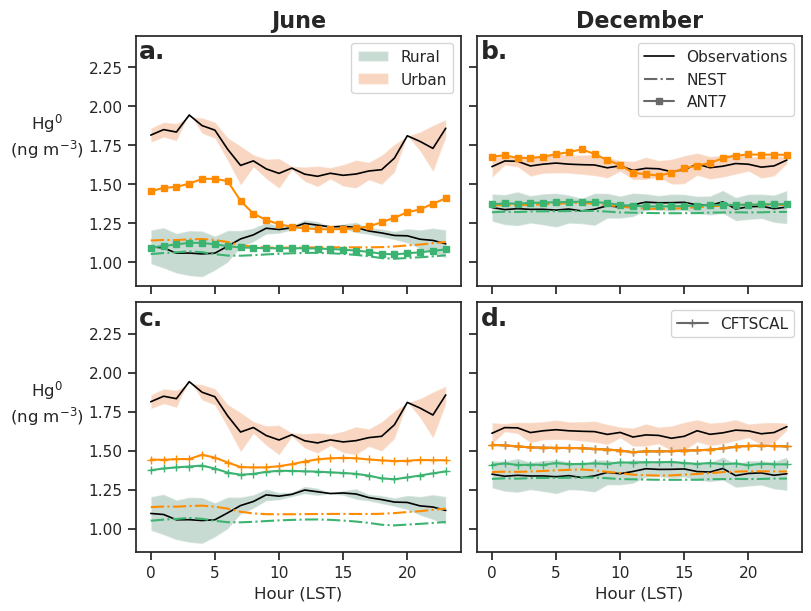

In [183]:
if figure2_5 == True:
    # ------------------------------------------------------------------
    # --- Compiling figure 5 since key data has already been read in ---
    # ------------------------------------------------------------------

    #first, reading in the ft, uw concentrations for urban and rural sites in June.
    #These np arrays were calculated in ___.py
    
    month = 6
    datapath = datapath = path+'GC_processed/'
    mstr = str(month).zfill(2)
    file = datapath+mstr+'/'
    site_rur = '44.25_-73.55'
    dom_rur = '42.25_43.25_-76.6_-74.65'

    site_urb = '40.67_-74.15'
    dom_urb = '39.75_40.75_-76.6_-74.65'

    #concentrations
    rural_ft_n = np.load(file+'rural_n_NEST_'+site_rur+'_ft.npy')
    rural_uw_n = np.load(file+'rural_n_NEST_'+dom_rur+'_uw.npy')
    rural_pb_n = np.load(file+'rural_n_NEST_'+site_rur+'_pbl.npy')
    urban_ft_n = np.load(file+'urban_n_NEST_'+site_urb+'_ft.npy')
    urban_uw_n = np.load(file+'urban_n_NEST_'+dom_urb+'_uw.npy')
    urban_pb_n = np.load(file+'urban_n_NEST_'+site_urb+'_pbl.npy')

    #3x
    rural_ft_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_ft.npy')
    rural_uw_n3x = np.load(file+'rural_n_ANT3-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_ft.npy')
    urban_uw_n3x = np.load(file+'urban_n_ANT3-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_pbl.npy')

    #7x
    rural_ft_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_ft.npy')
    rural_uw_n7x = np.load(file+'rural_n_ANT7-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_ft.npy')
    urban_uw_n7x = np.load(file+'urban_n_ANT7-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_pbl.npy')

    #10x
    rural_ft_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_ft.npy')
    rural_uw_n10x = np.load(file+'rural_n_ANT10-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_ft.npy')
    urban_uw_n10x = np.load(file+'urban_n_ANT10-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_pbl.npy')

    #3xnes
    rural_ft_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_ft.npy')
    rural_uw_n3xnes = np.load(file+'rural_n_ANT3_'+dom_rur+'_uw.npy')
    rural_pb_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_pbl.npy')
    urban_ft_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_ft.npy')
    urban_uw_n3xnes = np.load(file+'urban_n_ANT3_'+dom_urb+'_uw.npy')
    urban_pb_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_pbl.npy')

    #7xnes
    rural_ft_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_ft.npy')
    rural_uw_n7xnes = np.load(file+'rural_n_ANT7_'+dom_rur+'_uw.npy')
    rural_pb_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_pbl.npy')
    urban_ft_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_ft.npy')
    urban_uw_n7xnes = np.load(file+'urban_n_ANT7_'+dom_urb+'_uw.npy')
    urban_pb_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_pbl.npy')

    #10xnes
    rural_ft_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_ft.npy')
    rural_uw_n10xnes = np.load(file+'rural_n_ANT10_'+dom_rur+'_uw.npy')
    rural_pb_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_pbl.npy')
    urban_ft_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_ft.npy')
    urban_uw_n10xnes = np.load(file+'urban_n_ANT10_'+dom_urb+'_uw.npy')
    urban_pb_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_pbl.npy')
    
    #FTscale
    rural_ft_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_ft.npy')
    rural_uw_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+dom_rur+'_uw.npy')
    rural_pb_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_pbl.npy')
    urban_ft_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_ft.npy')
    urban_uw_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+dom_urb+'_uw.npy')
    urban_pb_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_pbl.npy')

    #FTscale (tuned)
    rural_ft_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_ft.npy')
    rural_uw_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+dom_rur+'_uw.npy')
    rural_pb_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_pbl.npy')
    urban_ft_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_ft.npy')
    urban_uw_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+dom_urb+'_uw.npy')
    urban_pb_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_pbl.npy')

    urban_test_j = pd.DataFrame({'time':pd.date_range('6-01-2019','07-01-2019',freq='1H')[0:-1],'u_std':urban_pb_n,'u_3x':urban_pb_n3x,'u_7x':urban_pb_n7x,'u_10x':urban_pb_n10x,'u_3xnes':urban_pb_n3xnes,'u_7xnes':urban_pb_n7xnes,'u_10xnes':urban_pb_n10xnes,'u_ftscale':urban_pb_ftscale,'u_ftscale_t':urban_pb_ftscale_t})    
    urban_test_j = urban_test_j.set_index('time').shift(-5)
    urban_test_j['hour'] = urban_test_j.index.hour
    urban_test_j = urban_test_j.groupby('hour').mean()

    rural_test_j = pd.DataFrame({'time':pd.date_range('6-01-2019','7-01-2019',freq='1H')[0:-1],'r_std':rural_pb_n,'r_3x':rural_pb_n3x,'r_7x':rural_pb_n7x,'r_10x':rural_pb_n10x,'r_3xnes':rural_pb_n3xnes,'r_7xnes':rural_pb_n7xnes,'r_10xnes':rural_pb_n10xnes,'r_ftscale':rural_pb_ftscale,'r_ftscale_t':rural_pb_ftscale_t})
    rural_test_j = rural_test_j.set_index('time').shift(-5)
    rural_test_j['hour'] = rural_test_j.index.hour
    rural_test_j = rural_test_j.groupby('hour').mean()

    #now reading in GC data from December

    #first, reading in the ft, uw concentrations for urban and rural
    month = 12
    datapath = path+'GC_processed/'
    mstr = str(month).zfill(2)
    file = datapath+mstr+'/'
    site_rur = '44.25_-73.55'
    dom_rur = '42.25_43.25_-76.6_-74.65'

    site_urb = '40.67_-74.15'
    dom_urb = '39.75_40.75_-76.6_-74.65'

    #concentrations
    rural_ft_n = np.load(file+'rural_n_NEST_'+site_rur+'_ft.npy')
    rural_uw_n = np.load(file+'rural_n_NEST_'+dom_rur+'_uw.npy')
    rural_pb_n = np.load(file+'rural_n_NEST_'+site_rur+'_pbl.npy')
    urban_ft_n = np.load(file+'urban_n_NEST_'+site_urb+'_ft.npy')
    urban_uw_n = np.load(file+'urban_n_NEST_'+dom_urb+'_uw.npy')
    urban_pb_n = np.load(file+'urban_n_NEST_'+site_urb+'_pbl.npy')

    #3x
    rural_ft_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_ft.npy')
    rural_uw_n3x = np.load(file+'rural_n_ANT3-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_ft.npy')
    urban_uw_n3x = np.load(file+'urban_n_ANT3-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_pbl.npy')

    #7x
    rural_ft_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_ft.npy')
    rural_uw_n7x = np.load(file+'rural_n_ANT7-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_ft.npy')
    urban_uw_n7x = np.load(file+'urban_n_ANT7-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_pbl.npy')

    #10x
    rural_ft_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_ft.npy')
    rural_uw_n10x = np.load(file+'rural_n_ANT10-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_ft.npy')
    urban_uw_n10x = np.load(file+'urban_n_ANT10-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_pbl.npy')

    #3xnes
    rural_ft_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_ft.npy')
    rural_uw_n3xnes = np.load(file+'rural_n_ANT3_'+dom_rur+'_uw.npy')
    rural_pb_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_pbl.npy')
    urban_ft_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_ft.npy')
    urban_uw_n3xnes = np.load(file+'urban_n_ANT3_'+dom_urb+'_uw.npy')
    urban_pb_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_pbl.npy')

    #7xnes
    rural_ft_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_ft.npy')
    rural_uw_n7xnes = np.load(file+'rural_n_ANT7_'+dom_rur+'_uw.npy')
    rural_pb_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_pbl.npy')
    urban_ft_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_ft.npy')
    urban_uw_n7xnes = np.load(file+'urban_n_ANT7_'+dom_urb+'_uw.npy')
    urban_pb_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_pbl.npy')

    #10xnes
    rural_ft_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_ft.npy')
    rural_uw_n10xnes = np.load(file+'rural_n_ANT10_'+dom_rur+'_uw.npy')
    rural_pb_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_pbl.npy')
    urban_ft_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_ft.npy')
    urban_uw_n10xnes = np.load(file+'urban_n_ANT10_'+dom_urb+'_uw.npy')
    urban_pb_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_pbl.npy')
    
    #FTscale
    rural_ft_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_ft.npy')
    rural_uw_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+dom_rur+'_uw.npy')
    rural_pb_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_pbl.npy')
    urban_ft_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_ft.npy')
    urban_uw_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+dom_urb+'_uw.npy')
    urban_pb_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_pbl.npy')

    #FTscale (tuned)
    rural_ft_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_ft.npy')
    rural_uw_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+dom_rur+'_uw.npy')
    rural_pb_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_pbl.npy')
    urban_ft_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_ft.npy')
    urban_uw_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+dom_urb+'_uw.npy')
    urban_pb_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_pbl.npy')
    
    #combining into urban december df
    urban_test_d = pd.DataFrame({'time':pd.date_range('12-01-2019','01-01-2020',freq='1H')[0:-1],'u_std':urban_pb_n,'u_3x':urban_pb_n3x,'u_7x':urban_pb_n7x,'u_10x':urban_pb_n10x,'u_3xnes':urban_pb_n3xnes,'u_7xnes':urban_pb_n7xnes,'u_10xnes':urban_pb_n10xnes,'u_ftscale':urban_pb_ftscale,'u_ftscale_t':urban_pb_ftscale_t})    
    urban_test_d = urban_test_d.set_index('time').shift(-5)
    urban_test_d['hour'] = urban_test_d.index.hour
    urban_test_d = urban_test_d.groupby('hour').mean()
    
    rural_test_d = pd.DataFrame({'time':pd.date_range('12-01-2019','01-01-2020',freq='1H')[0:-1],'r_std':rural_pb_n,'r_3x':rural_pb_n3x,'r_7x':rural_pb_n7x,'r_10x':rural_pb_n10x,'r_3xnes':rural_pb_n3xnes,'r_7xnes':rural_pb_n7xnes,'r_10xnes':rural_pb_n10xnes,'r_ftscale':rural_pb_ftscale,'r_ftscale_t':rural_pb_ftscale_t})
    rural_test_d = rural_test_d.set_index('time').shift(-5)
    rural_test_d['hour'] = rural_test_d.index.hour
    rural_test_d = rural_test_d.groupby('hour').mean()

    # -------------------------------------
    # --- Figure 5 plotting/compilation ---
    # -------------------------------------
    
    fig,ax=plt.subplots(2,2,figsize=(8,6),sharex=True,sharey=True,layout='constrained')

    ufill = ax[0,0].fill_between(NY06.index, NY06['GEM'], NJ30['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    rfill = ax[0,0].fill_between(NY20.index, NY20['GEM'], VT99['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)
    uline, = ax[0,0].plot(NY06.index,(NY06['GEM']+NJ30['GEM'])/2,c='black',linewidth=1.2)
    rline, = ax[0,0].plot(NY20.index,(NY20['GEM']+VT99['GEM'])/2,c='black',linewidth=1.2)

    ax[0,0].plot(urban_test_j['u_std'],c='darkorange',label='GEOS-Chem',linestyle='-.')
    ax[0,0].plot(urban_test_j['u_7xnes'],c='darkorange',marker='s',label='GEOS-Chem (10xAnthro)',markersize=4)

    ax[0,0].plot(rural_test_j['r_std'],c='mediumseagreen',label='GEOS-Chem',linestyle='-.')
    ax[0,0].plot(rural_test_j['r_7xnes'],c='mediumseagreen',marker='s',label='GEOS-Chem (10xAnthro)',markersize=4)

    #adding legend
    #ax[0,0].legend([(rfill, rline),(ufill, uline)], ['Rural','Urban'],loc='upper right',title='Regional Obs.')
    ax[0,0].legend([rfill,ufill], ['Rural','Urban'],loc='upper right')
    
    ax[0,1].fill_between(NY06_d.index, NY06_d['GEM'], NJ30_d['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    ax[0,1].fill_between(NY20_d.index, NY20_d['GEM'], VT99_d['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)
    ax[0,1].plot(NY06_d.index,(NY06_d['GEM']+NJ30_d['GEM'])/2,c='black',linewidth=1.2)
    ax[0,1].plot(NY20_d.index,(NY20_d['GEM']+VT99_d['GEM'])/2,c='black',linewidth=1.2,label='Observations')

    ax[0,1].plot(urban_test_d['u_std'],c='darkorange',linestyle='-.')
    ax[0,1].plot(urban_test_d['u_7xnes'],c='darkorange',marker='s',markersize=4)

    ax[0,1].plot(rural_test_d['r_std']*10,c='dimgray',label='NEST',linestyle='-.')
    ax[0,1].plot(rural_test_d['r_7xnes']*10,c='dimgray',marker='s',label='ANT7',markersize=4)

    ax[0,1].plot(rural_test_d['r_std'],c='mediumseagreen',linestyle='-.')
    ax[0,1].plot(rural_test_d['r_7xnes'],c='mediumseagreen',marker='s',markersize=4)
    ax[0,1].legend(loc='upper right')

    ax[0,0].set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

    #lower panels
    ax[1,0].fill_between(NY06.index, NY06['GEM'], NJ30['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    ax[1,0].fill_between(NY20.index, NY20['GEM'], VT99['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)
    ax[1,0].plot(NY06.index,(NY06['GEM']+NJ30['GEM'])/2,c='black',linewidth=1.2)
    ax[1,0].plot(NY20.index,(NY20['GEM']+VT99['GEM'])/2,c='black',linewidth=1.2)
    
    ax[1,0].plot(rural_test_j['r_std'],c='mediumseagreen',linestyle='-.')
    ax[1,0].plot(urban_test_j['u_std'],c='darkorange',linestyle='-.')
    ax[1,0].plot(rural_test_j['r_ftscale_t'],c='mediumseagreen',marker='+')
    ax[1,0].plot(urban_test_j['u_ftscale_t'],c='darkorange',marker='+')

    ax[1,1].fill_between(NY06_d.index, NY06_d['GEM'], NJ30_d['GEM'],color='#e87832',alpha=0.3,edgecolor=None)
    ax[1,1].fill_between(NY20_d.index, NY20_d['GEM'], VT99_d['GEM'],color='#4a8a6f',alpha=0.3,edgecolor=None)
    ax[1,1].plot(NY06_d.index,(NY06_d['GEM']+NJ30_d['GEM'])/2,c='black',linewidth=1.2)
    ax[1,1].plot(NY20_d.index,(NY20_d['GEM']+VT99_d['GEM'])/2,c='black',linewidth=1.2)
    
    ax[1,1].plot(rural_test_d['r_std'],c='mediumseagreen',linestyle='-.')
    ax[1,1].plot(urban_test_d['u_std'],c='darkorange',linestyle='-.')
    ax[1,1].plot(urban_test_d['u_ftscale_t'],c='dimgray',marker='+',label='CFTSCAL')
    ax[1,1].plot(rural_test_d['r_ftscale_t'],c='mediumseagreen',marker='+')
    ax[1,1].plot(urban_test_d['u_ftscale_t'],c='darkorange',marker='+')

    ax[1,1].legend(loc='upper right')
    
    ax[1,0].set_ylabel('Hg$^{0}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)
    ax[1,0].set_xlabel('Hour (LST)')
    ax[1,1].set_xlabel('Hour (LST)')
    ax[0,0].set_ylim(0.85,2.45)

    #add some axis labels
    ax[0,0].annotate('a.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax[0,1].annotate('b.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax[1,0].annotate('c.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')
    ax[1,1].annotate('d.', xy=(0.01, 0.985), xycoords='axes fraction',fontsize=18, fontweight='bold', va='top', ha='left')

    #add some titles
    ax[0,0].set_title('June',fontsize=16,fontweight='bold')
    ax[0,1].set_title('December',fontsize=16,fontweight='bold')
    
    #specify yticks
    ax[0,0].set_yticks([1,1.25,1.5,1.75,2,2.25])
    
    plt.savefig(figpath+'Fig5_4panel_EST.'+figformat,dpi=dpi,transparent=True)


In [184]:
obs_diff = ((NY06['GEM']+NJ30['GEM'])/2).mean()-((NY20['GEM']+VT99['GEM'])/2).mean()
mod_diff = (urban_test_j['u_std']-rural_test_j['r_std']).mean()
((obs_diff-mod_diff)/obs_diff)*100

87.91644828106587

In [185]:
obs_diff = ((NY06_d['GEM']+NJ30_d['GEM'])/2).mean()-((NY20_d['GEM']+VT99_d['GEM'])/2).mean()
mod_diff = (urban_test_d['u_std']-rural_test_d['r_std']).mean()
((obs_diff-mod_diff)/obs_diff)*100

84.19636035339519

In [186]:
if figure3 == True:
    
    month = 6
    file = 'GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'
    #reading in GEOS-Chem datasets (s = std res, n = nested res)
    base_s = xr.open_mfdataset(path+'/GC_output/STND/'+file)
    base_n = xr.open_mfdataset(path+'/GC_output/NEST/'+file)

    
    EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
    BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
    MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

    #processing pbl data for nearby airports
    pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                            'BDL_pblh':BDL_df['pblh'],
                            'MHT_pblh':MHT_df['pblh'],
                            'EWR_windmag':EWR_df['windmag'],
                            'BDL_windmag':BDL_df['windmag'],
                            'MHT_windmag':MHT_df['windmag']})

    pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
    pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

    pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
    pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()

    ### Reading in NADP data ###
    Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
    Amnet['collStart'] = pd.to_datetime(Amnet['collStart'])
    Amnet['collEnd'] = pd.to_datetime(Amnet['collEnd'])
    Amnet = Amnet.set_index('collStart')

    #subsetting sites of interest
    start = '2011-01-01'#'2014-01-01'
    end = '2020-01-01'

    Amnet = Amnet[Amnet.index>start]
    Amnet = Amnet[Amnet.index<end]
    Amnet_all = Amnet.copy()
    Amnet = Amnet[Amnet.index.month==month]
    Amnet['hour'] = Amnet.index.hour 

    #extracting monthly diel cycles for all interesting sites
    NJ54 = Amnet[Amnet['SiteID']=='NJ54'].groupby('hour').mean()
    NJ30 = Amnet[Amnet['SiteID']=='NJ30'].groupby('hour').mean()
    NY06 = Amnet[Amnet['SiteID']=='NY06'].groupby('hour').mean()
    NY20 = Amnet[Amnet['SiteID']=='NY20'].groupby('hour').mean()
    VT99 = Amnet[Amnet['SiteID']=='VT99'].groupby('hour').mean()
    MD08 = Amnet[Amnet['SiteID']=='MD08'].groupby('hour').mean()
    MD99 = Amnet[Amnet['SiteID']=='MD98'].groupby('hour').mean()
    NJ05 = Amnet[Amnet['SiteID']=='NJ05'].groupby('hour').mean()

    NJ30_h = Amnet_all[Amnet_all['SiteID']=='NJ30']
    NY06_h = Amnet_all[Amnet_all['SiteID']=='NY06']
    NY20_h = Amnet_all[Amnet_all['SiteID']=='NY20']
    VT99_h = Amnet_all[Amnet_all['SiteID']=='VT99']

    # --- making df with key observations ---
    measurements = pd.merge(NY20['GEM'],NY06['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM_x':'NY20','GEM_y':'NY06'})
    measurements = pd.merge(measurements,NJ30['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM':'NJ30'})
    measurements = pd.merge(measurements,VT99['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM':'VT99'})
    measurements['urban'] = ((measurements['NY06'].interpolate()+measurements['NJ30'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
    measurements['rural'] = ((measurements['NY20'].interpolate()+measurements['VT99'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
    
    urban_ss = np.load('../../data/boxmod_opt/flux_urban_solspace_06.npy')
    rural_ss = np.load('../../data/boxmod_opt/flux_rural_solspace_06.npy')

    uw_conc = np.linspace(1,2,40)
    ft_conc = np.linspace(1,2,40)

    #need to set up a loop that first goes to each array in urban_ss and then goes to each value in that subarray

    for i in list(range(0,40)):

        rural_i = rural_ss[i,:]
        ft_conc_i = ft_conc[i]

        for j in list(range(0,40)):
            amp_j = f.amplitude_calc(f.box_model(rural_i[j],pbl,measurements,upw_conc=uw_conc[j],hg_ft=ft_conc_i,groupby=True)['hg_box'])

            if j==0:
                amp_ar = np.array([amp_j])
            else:
                amp_ar = np.append(amp_ar,amp_j)

        if i == 0:
            amplitude = amp_ar
        else:
            amplitude = np.vstack((amplitude,amp_ar))

    # full coordinate arrays
    xx, yy = np.meshgrid(uw_conc,ft_conc)

    rural_lb = f.amplitude_calc(measurements['rural'])*0.5
    rural_ub = f.amplitude_calc(measurements['rural'])*1.5

    rural_prior = 0

    # --- Defining constrained solution space (rural, June) ---

    #first, check for lower bound of amplitude
    amp_lb = np.where(amplitude>rural_lb,1,0)

    #second, check for upper bound of amplitude
    amp_ub = np.where(amplitude<rural_ub,1,0)

    #third, check for lower bound of ft concentrations
    ft_lb = np.where(yy>measurements['rural'].max(),1,0)

    #fourth, check upper bound of ft concentrations
    ft_ub = np.where(yy<measurements['urban'].min(),1,0)

    #sixth, check if greater than [name existing flux constraint]
    flux_lb = np.where(rural_ss<rural_prior,0.5,0)

    #fifth, check if extra bound is met
    midday_avg = (measurements['urban'].min()+measurements['rural'].max())/2
    ft_eb = np.where(yy<midday_avg,0.25,0)

    #add up constraints met
    cs = ft_ub+ft_lb+amp_ub+amp_lb+flux_lb+ft_eb

    #Amplitude space
    amp_space_rural = amp_lb+amp_ub

    #keep only top two levels for shading in final plots
    constrained_space_rural = np.where(cs>=4,cs,0)

    # --- Now repeating for urban (June) ---
    for i in list(range(0,40)):

        urban_i = urban_ss[i,:]
        ft_conc_i = ft_conc[i]

        for j in list(range(0,40)):
            amp_j = f.amplitude_calc(f.box_model(urban_i[j],pbl,measurements,upw_conc=uw_conc[j],hg_ft=ft_conc_i,groupby=True)['hg_box'])

            if j==0:
                amp_ar = np.array([amp_j])
            else:
                amp_ar = np.append(amp_ar,amp_j)

        if i == 0:
            amplitude = amp_ar
        else:
            amplitude = np.vstack((amplitude,amp_ar))

    # full coordinate arrays
    urban_lb = f.amplitude_calc(measurements['urban'])*0.5
    urban_ub = f.amplitude_calc(measurements['urban'])*1.5

    urban_prior = 0

    #urban case

    #first, check for lower bound of amplitude
    amp_lb = np.where(amplitude>urban_lb,1,0)

    #second, check for upper bound of amplitude
    amp_ub = np.where(amplitude<urban_ub,1,0)

    #third, check for lower bound of ft concentrations
    ft_lb = np.where(yy>measurements['rural'].max(),1,0)
    #midday_avg = (measurements['urban'].min()+measurements['rural'].max())/2
    #ft_lb = np.where(yy>(midday_avg),1,0)

    #fourth, check upper bound of ft concentrations
    ft_ub = np.where(yy<measurements['urban'].min(),1,0)

    #sixth, check if greater than [name existing flux constraint]
    flux_lb = np.where(urban_ss>urban_prior,0.5,0)

    #fifth, check if extra bound is met
    midday_avg = (measurements['urban'].min()+measurements['rural'].max())/2
    ft_eb = np.where(yy>midday_avg,0.25,0)

    #add up constraints met
    cs = ft_ub+ft_lb+amp_ub+amp_lb+flux_lb+ft_eb

    #Amplitude space
    amp_space_urban = amp_lb+amp_ub

    #keep only top two levels for shading in final plots
    constrained_space_urban = np.where(cs>=4,cs,0)

    # --- Now reading in the boundary conditions from GEOS-Chem ---

    #first, reading in the ft, uw concentrations for urban and rural
    datapath = path+'GC_processed/'
    mstr = str(month).zfill(2)
    file = datapath+mstr+'/'
    site_rur = '44.25_-73.55'
    dom_rur = '42.25_43.25_-76.6_-74.65'

    site_urb = '40.67_-74.15'
    dom_urb = '39.75_40.75_-76.6_-74.65'

    #concentrations
    rural_ft_n = np.load(file+'rural_n_NEST_'+site_rur+'_ft.npy')
    rural_uw_n = np.load(file+'rural_n_NEST_'+dom_rur+'_uw.npy')
    rural_pb_n = np.load(file+'rural_n_NEST_'+site_rur+'_pbl.npy')
    urban_ft_n = np.load(file+'urban_n_NEST_'+site_urb+'_ft.npy')
    urban_uw_n = np.load(file+'urban_n_NEST_'+dom_urb+'_uw.npy')
    urban_pb_n = np.load(file+'urban_n_NEST_'+site_urb+'_pbl.npy')

    #3x
    rural_ft_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_ft.npy')
    rural_uw_n3x = np.load(file+'rural_n_ANT3-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_ft.npy')
    urban_uw_n3x = np.load(file+'urban_n_ANT3-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_pbl.npy')

    #7x
    rural_ft_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_ft.npy')
    rural_uw_n7x = np.load(file+'rural_n_ANT7-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_ft.npy')
    urban_uw_n7x = np.load(file+'urban_n_ANT7-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_pbl.npy')

    #10x
    rural_ft_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_ft.npy')
    rural_uw_n10x = np.load(file+'rural_n_ANT10-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_ft.npy')
    urban_uw_n10x = np.load(file+'urban_n_ANT10-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_pbl.npy')

    #3xnes
    rural_ft_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_ft.npy')
    rural_uw_n3xnes = np.load(file+'rural_n_ANT3_'+dom_rur+'_uw.npy')
    rural_pb_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_pbl.npy')
    urban_ft_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_ft.npy')
    urban_uw_n3xnes = np.load(file+'urban_n_ANT3_'+dom_urb+'_uw.npy')
    urban_pb_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_pbl.npy')

    #7xnes
    rural_ft_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_ft.npy')
    rural_uw_n7xnes = np.load(file+'rural_n_ANT7_'+dom_rur+'_uw.npy')
    rural_pb_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_pbl.npy')
    urban_ft_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_ft.npy')
    urban_uw_n7xnes = np.load(file+'urban_n_ANT7_'+dom_urb+'_uw.npy')
    urban_pb_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_pbl.npy')

    #10xnes
    rural_ft_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_ft.npy')
    rural_uw_n10xnes = np.load(file+'rural_n_ANT10_'+dom_rur+'_uw.npy')
    rural_pb_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_pbl.npy')
    urban_ft_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_ft.npy')
    urban_uw_n10xnes = np.load(file+'urban_n_ANT10_'+dom_urb+'_uw.npy')
    urban_pb_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_pbl.npy')
    
    #FTscale
    rural_ft_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_ft.npy')
    rural_uw_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+dom_rur+'_uw.npy')
    rural_pb_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_pbl.npy')
    urban_ft_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_ft.npy')
    urban_uw_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+dom_urb+'_uw.npy')
    urban_pb_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_pbl.npy')

    #FTscale (tuned)
    rural_ft_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_ft.npy')
    rural_uw_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+dom_rur+'_uw.npy')
    rural_pb_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_pbl.npy')
    urban_ft_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_ft.npy')
    urban_uw_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+dom_urb+'_uw.npy')
    urban_pb_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_pbl.npy')

    def gc_netHg0(file,filename,method='mean'):
        n_f = xr.open_dataset(file+filename)
        n_f['net_ngm2hr'] = n_f['EmisTot_ngm2hr']-n_f['DryDep_Hg0_ngm2hr']

        if method == 'mean':
            r_flux = (((n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest')))/2).values
            u_flux = (((n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest')))/2).values

        if method == 'max':
            r_flux = np.min([n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest').values])
            u_flux = np.max([n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').values])

        return r_flux,u_flux


    r_f,u_f = gc_netHg0(file,'NetHg0Flux_'+mstr+'.nc4')
    r_f3x,u_f3x = gc_netHg0(file,'NetHg0Flux_3x_'+mstr+'.nc4')
    r_f7x,u_f7x = gc_netHg0(file,'NetHg0Flux_7x_'+mstr+'.nc4')
    r_f10x,u_f10x = gc_netHg0(file,'NetHg0Flux_10x_'+mstr+'.nc4')
    
    r_f3xnes,u_f3xnes = gc_netHg0(file,'NetHg0Flux_3x_NEscale_'+mstr+'.nc4')
    r_f7xnes,u_f7xnes = gc_netHg0(file,'NetHg0Flux_7x_NEscale_'+mstr+'.nc4')
    r_f10xnes,u_f10xnes = gc_netHg0(file,'NetHg0Flux_10x_NEscale_'+mstr+'.nc4')

    #making cmap
    top = cm.get_cmap('Blues_r', 128)
    bottom = cm.get_cmap('Reds', 128)

    newcolors = np.vstack((top(np.linspace(0.1, 0.9, 128)),
                           bottom(np.linspace(0.1, 0.9, 128))))
    newcmp = ListedColormap(newcolors, name='OrangeBlue')

    Levels = [-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70]
    norm = colors.BoundaryNorm(boundaries=Levels, ncolors=260,extend='both') #256
    cmap = newcmp
    lev = len(Levels)

    test_rural = np.where(constrained_space_rural<4.5,np.nan,constrained_space_rural)
    test_urban = np.where(constrained_space_urban<4.5,np.nan,constrained_space_urban)

/tmp/ipykernel_907/1093336360.py:29: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) inste

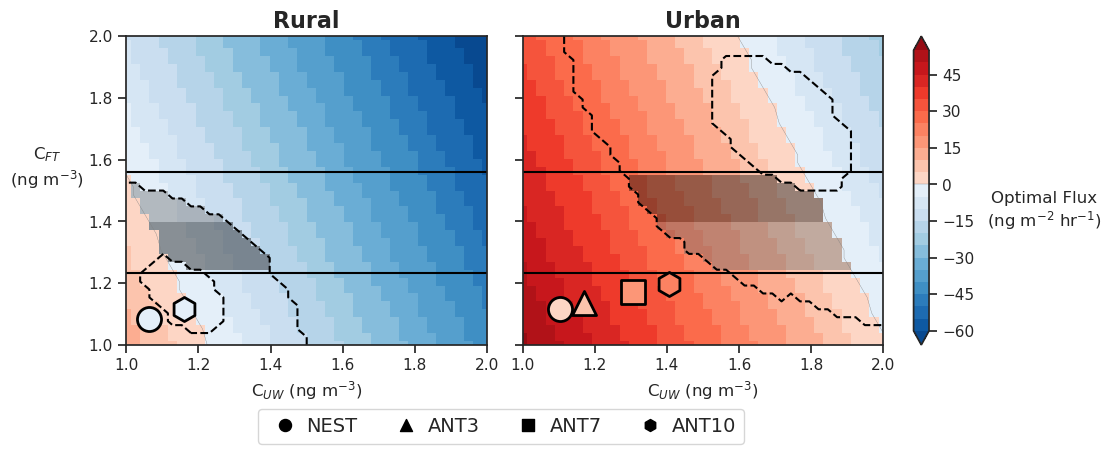

In [187]:
if figure3 == True:
    # -------------------------------------
    # --- Figure 3 plotting/compilation ---
    # -------------------------------------

    #now, lets make one two-panel plot featuring the urban and rural results.
    alpha = 0.4

    bounds = np.arange(-60, 60, 5)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

    bounds_shade = np.array([0,2,4,4.74,4.76])#np.array([0,0.9,1.4,2])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    fig,ax=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True,layout='constrained')
    g = ax[0].pcolormesh(uw_conc,ft_conc,rural_ss,norm=norm,cmap=cmap)

    #geoschem
    g = ax[0].scatter(np.nanmean(rural_uw_n),np.nanmean(rural_ft_n),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[0].scatter(np.nanmean(rural_uw_n10xnes),np.nanmean(rural_ft_n10xnes),c=[r_f10xnes],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')
    
    ax[0].contour(uw_conc,ft_conc,rural_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[0].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[0].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[0].contour(uw_conc,ft_conc,amp_space_rural,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[0].pcolormesh(uw_conc,ft_conc,test_rural,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
    ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)
    
    g = ax[1].pcolormesh(uw_conc,ft_conc,urban_ss,norm=norm,cmap=cmap)

    #geoschem
    ax[1].scatter(np.nanmean(urban_uw_n),np.nanmean(urban_ft_n),c=[u_f],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[1].scatter(np.nanmean(urban_uw_n3xnes),np.nanmean(urban_ft_n3xnes),c=[u_f3xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7xnes),np.nanmean(urban_ft_n7xnes),c=[u_f7xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10xnes),np.nanmean(urban_ft_n10xnes),c=[u_f10xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[1].contour(uw_conc,ft_conc,urban_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[1].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[1].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[1].contour(uw_conc,ft_conc,amp_space_urban,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[1].pcolormesh(uw_conc,ft_conc,test_urban,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    
    ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

    cbar = fig.colorbar(g)
    cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=50)
    cbar.ax.axhline(0, c='gray',linewidth=0.25)

    #setting x/y lims
    ax[0].set_xlim(1,2)
    ax[0].set_ylim(1,2)
    
    #adding in a legend
    ax[1].scatter(-1,-1,c='black',s=300,marker='o',label='NEST')
    ax[1].scatter(-1,-1,c='black',s=300,marker='^',label='ANT3')
    ax[1].scatter(-1,-1,c='black',s=300,marker='s',label='ANT7')
    ax[1].scatter(-1,-1,c='black',s=300,marker='h',label='ANT10')

    fig.legend(loc='lower center',
               ncol=4,
               markerscale=0.5,
               bbox_to_anchor=(0.45,-0.12),
               columnspacing=1.5,
               handletextpad=0.1,
               fontsize=14,
               scatteryoffsets=[0.5])
    
    #adding in titles
    ax[0].set_title('Rural',fontsize=16,fontweight='bold')
    ax[1].set_title('Urban',fontsize=16,fontweight='bold')
    plt.savefig(figpath+'Fig3_EST.'+figformat,dpi=dpi,transparent=True,bbox_inches = "tight")


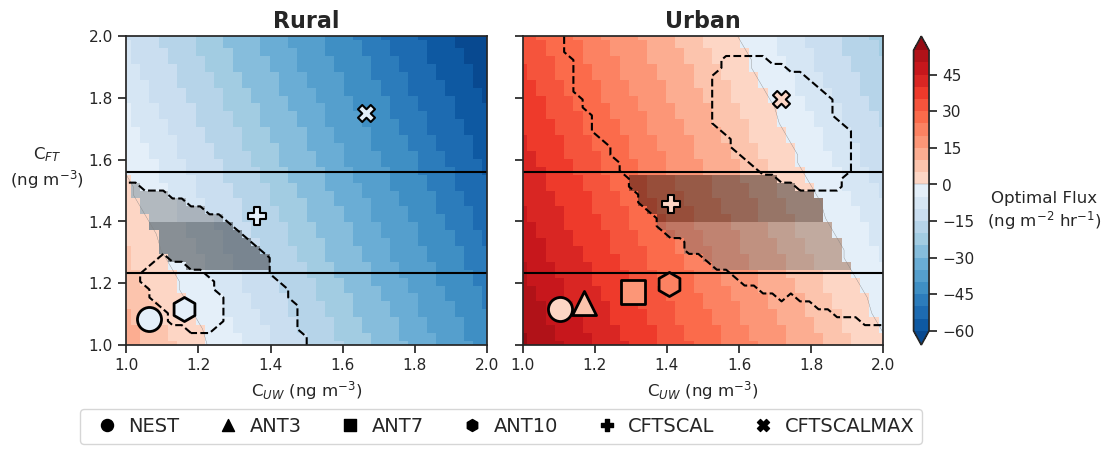

In [188]:
if figure3 == True:
    # -------------------------------------
    # --- Figure 3 plotting/compilation ---
    # -------------------------------------

    #now, lets make one two-panel plot featuring the urban and rural results.
    alpha = 0.4

    bounds = np.arange(-60, 60, 5)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

    bounds_shade = np.array([0,2,4,4.74,4.76])#np.array([0,0.9,1.4,2])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    fig,ax=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True,layout='constrained')
    g = ax[0].pcolormesh(uw_conc,ft_conc,rural_ss,norm=norm,cmap=cmap)

    #geoschem
    g = ax[0].scatter(np.nanmean(rural_uw_n),np.nanmean(rural_ft_n),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[0].scatter(np.nanmean(rural_uw_n10xnes),np.nanmean(rural_ft_n10xnes),c=[r_f10xnes],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')
    
    ax[0].contour(uw_conc,ft_conc,rural_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[0].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[0].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[0].contour(uw_conc,ft_conc,amp_space_rural,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[0].pcolormesh(uw_conc,ft_conc,test_rural,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
    ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

    #ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),marker='+',c='black',s=200)
    #ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),marker='2',c='black',s=200)
    
    ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')#,linestyle='-.')
    ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')#,linestyle=':')    
    
    g = ax[1].pcolormesh(uw_conc,ft_conc,urban_ss,norm=norm,cmap=cmap)

    #geoschem
    ax[1].scatter(np.nanmean(urban_uw_n),np.nanmean(urban_ft_n),c=[u_f],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[1].scatter(np.nanmean(urban_uw_n3xnes),np.nanmean(urban_ft_n3xnes),c=[u_f3xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7xnes),np.nanmean(urban_ft_n7xnes),c=[u_f7xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10xnes),np.nanmean(urban_ft_n10xnes),c=[u_f10xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[1].contour(uw_conc,ft_conc,urban_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[1].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[1].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[1].contour(uw_conc,ft_conc,amp_space_urban,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[1].pcolormesh(uw_conc,ft_conc,test_urban,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],

    #ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),marker='+',c='black',s=200)
    #ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),marker='2',c='black',s=200)

    ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')
    ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')
    
    ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

    cbar = fig.colorbar(g)
    cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=50)
    cbar.ax.axhline(0, c='gray',linewidth=0.25)
    
    #setting x/y lims
    ax[0].set_xlim(1,2)
    ax[0].set_ylim(1,2)
    
    #adding in a legend
    ax[1].scatter(-1,-1,c='black',s=300,marker='o',label='NEST')
    ax[1].scatter(-1,-1,c='black',s=300,marker='^',label='ANT3')
    ax[1].scatter(-1,-1,c='black',s=300,marker='s',label='ANT7')
    ax[1].scatter(-1,-1,c='black',s=300,marker='h',label='ANT10')
    ax[1].scatter(-1,-1,c='black',s=300,marker='P',label='CFTSCAL')
    ax[1].scatter(-1,-1,c='black',s=300,marker='X',label='CFTSCALMAX')

    fig.legend(loc='lower center',
               ncol=6,
               markerscale=0.5,
               bbox_to_anchor=(0.45,-0.12),
               columnspacing=1.5,
               handletextpad=0.1,
               fontsize=14,
               scatteryoffsets=[0.5])
    
    ax[0].set_title('Rural',fontsize=16,fontweight='bold')
    ax[1].set_title('Urban',fontsize=16,fontweight='bold')
    plt.savefig(figpath+'Fig3_wFTscale_EST.'+figformat,dpi=dpi,transparent=True,bbox_inches="tight")


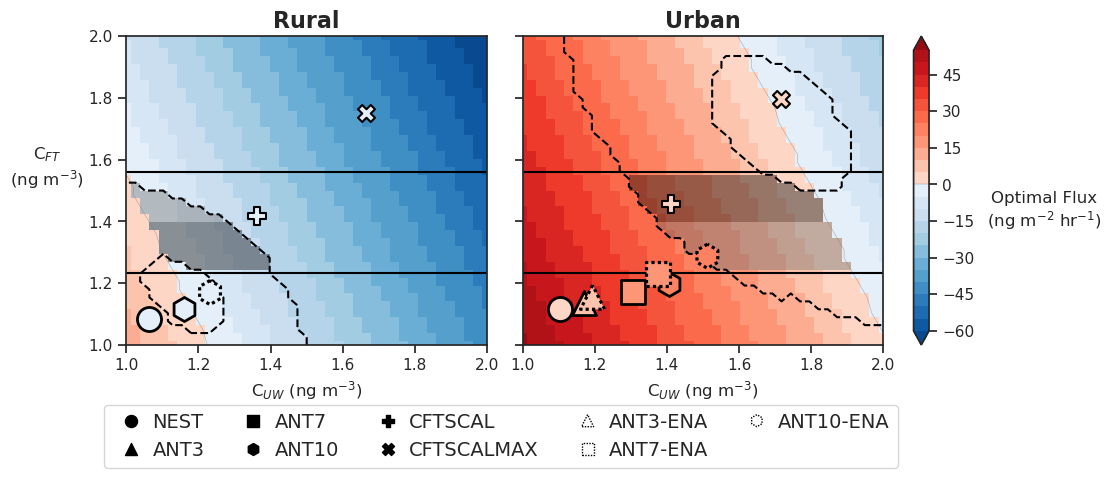

In [189]:
if figure3 == True:
    # -------------------------------------
    # --- Figure 3 plotting/compilation ---
    # -------------------------------------

    #now, lets make one two-panel plot featuring the urban and rural results.
    alpha = 0.4

    bounds = np.arange(-60, 60, 5)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

    bounds_shade = np.array([0,2,4,4.74,4.76])#np.array([0,0.9,1.4,2])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    fig,ax=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True,layout='constrained')
    g = ax[0].pcolormesh(uw_conc,ft_conc,rural_ss,norm=norm,cmap=cmap)

    #geoschem
    g = ax[0].scatter(np.nanmean(rural_uw_n),np.nanmean(rural_ft_n),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[0].scatter(np.nanmean(rural_uw_n10xnes),np.nanmean(rural_ft_n10xnes),c=[r_f10xnes],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')
    ax[0].scatter(np.nanmean(rural_uw_n10x),np.nanmean(rural_ft_n10x),c=[r_f10x],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='h')
    
    ax[0].contour(uw_conc,ft_conc,rural_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[0].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[0].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[0].contour(uw_conc,ft_conc,amp_space_rural,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[0].pcolormesh(uw_conc,ft_conc,test_rural,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
    ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

    #ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),marker='+',c='black',s=200)
    #ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),marker='2',c='black',s=200)
    
    ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')#,linestyle='-.')
    ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')#,linestyle=':')    
    
    g = ax[1].pcolormesh(uw_conc,ft_conc,urban_ss,norm=norm,cmap=cmap)

    #geoschem
    ax[1].scatter(np.nanmean(urban_uw_n),np.nanmean(urban_ft_n),c=[u_f],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[1].scatter(np.nanmean(urban_uw_n3xnes),np.nanmean(urban_ft_n3xnes),c=[u_f3xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7xnes),np.nanmean(urban_ft_n7xnes),c=[u_f7xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10xnes),np.nanmean(urban_ft_n10xnes),c=[u_f10xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[1].scatter(np.nanmean(urban_uw_n3x),np.nanmean(urban_ft_n3x),c=[u_f3x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7x),np.nanmean(urban_ft_n7x),c=[u_f7x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10x),np.nanmean(urban_ft_n10x),c=[u_f10x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='h')

    
    ax[1].contour(uw_conc,ft_conc,urban_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[1].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[1].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[1].contour(uw_conc,ft_conc,amp_space_urban,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[1].pcolormesh(uw_conc,ft_conc,test_urban,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],

    #ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),marker='+',c='black',s=200)
    #ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),marker='2',c='black',s=200)

    ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')
    ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')
    
    ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

    cbar = fig.colorbar(g)
    cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=50)
    cbar.ax.axhline(0, c='gray',linewidth=0.25)

    #setting x/y lims
    ax[0].set_xlim(1,2)
    ax[0].set_ylim(1,2)
    
    #adding in a legend
    ax[1].scatter(-1,-1,c='black',s=300,marker='o',label='NEST')
    ax[1].scatter(-1,-1,c='black',s=300,marker='^',label='ANT3')
    ax[1].scatter(-1,-1,c='black',s=300,marker='s',label='ANT7')
    ax[1].scatter(-1,-1,c='black',s=300,marker='h',label='ANT10')
    ax[1].scatter(-1,-1,c='black',s=300,marker='P',label='CFTSCAL')
    ax[1].scatter(-1,-1,c='black',s=300,marker='X',label='CFTSCALMAX')
    ax[1].scatter(-1,-1,c='white',edgecolor='black',s=300,marker='^',linestyle=(0, (1, 1)),label='ANT3-ENA')
    ax[1].scatter(-1,-1,c='white',edgecolor='black',s=300,marker='s',linestyle=(0, (1, 1)),label='ANT7-ENA')
    ax[1].scatter(-1,-1,c='white',edgecolor='black',s=300,marker='h',linestyle=(0, (1, 1)),label='ANT10-ENA')
    
    fig.legend(loc='lower center',
               ncol=5,
               markerscale=0.5,
               bbox_to_anchor=(0.45,-0.18),
               columnspacing=1.5,
               handletextpad=0.1,
               fontsize=14,
               scatteryoffsets=[0.5])

    ax[0].set_title('Rural',fontsize=16,fontweight='bold')
    ax[1].set_title('Urban',fontsize=16,fontweight='bold')
    plt.savefig(figpath+'Fig3_ENA_EST.'+figformat,dpi=dpi,transparent=True,bbox_inches='tight')


In [190]:
#now calculating percentage increases for manuscript
if figure3 == True:
    u = np.nanmean(rural_uw_n)
    us = np.nanmean(rural_uw_n10xnes)
    temp = (us-u)/u
    print('Rural % increase of uw concentrations: '+str(temp*100))

    u = np.nanmean(rural_ft_n)
    us = np.nanmean(rural_ft_n10xnes)
    temp = (us-u)/u
    print('Rural % increase of ft concentrations: '+str(temp*100))
  
    u = np.nanmean(urban_uw_n)
    us = np.nanmean(urban_uw_n10xnes)
    temp = (us-u)/u
    print('Urban % increase of uw concentrations: '+str(temp*100))

    u = np.nanmean(urban_ft_n)
    us = np.nanmean(urban_ft_n10xnes)
    temp = (us-u)/u
    print('Urban % increase of ft concentrations: '+str(temp*100))


Rural % increase of uw concentrations: 9.146929575860256
Rural % increase of ft concentrations: 2.984928801911414
Urban % increase of uw concentrations: 27.499448052484514
Urban % increase of ft concentrations: 7.148281679407352


In [191]:
#comparing fluxes
if figure3 == True:
    u = r_f
    us = r_f10x
    temp = (us-u)/u
    print('Rural change of net flux: '+str(temp))

    u = u_f
    us = u_f10x
    temp = (us-u)/u
    print('Rural change of net flux: '+str(temp))


Rural change of net flux: [-0.06923354]
Rural change of net flux: [15.799488]


In [192]:
if figure3 == True:
    u = np.nanmean(rural_uw_n)
    us = np.nanmean(rural_uw_n10x)
    temp = (us-u)/u
    print('Rural % increase of uw concentrations (ENA): '+str(temp*100))

    u = np.nanmean(rural_ft_n)
    us = np.nanmean(rural_ft_n10x)
    temp = (us-u)/u
    print('Rural % increase of ft concentrations (ENA): '+str(temp*100))
  
    u = np.nanmean(urban_uw_n)
    us = np.nanmean(urban_uw_n10x)
    temp = (us-u)/u
    print('Urban % increase of uw concentrations (ENA): '+str(temp*100))

    u = np.nanmean(urban_ft_n)
    us = np.nanmean(urban_ft_n10x)
    temp = (us-u)/u
    print('Urban % increase of ft concentrations (ENA): '+str(temp*100))


Rural % increase of uw concentrations (ENA): 16.05735160866973
Rural % increase of ft concentrations (ENA): 7.948501178897269
Urban % increase of uw concentrations (ENA): 37.06566965333092
Urban % increase of ft concentrations (ENA): 15.258331396206385


In [193]:
if figure4 == True:
    
    month = 12

    file = 'GEOSChem.SpeciesConcHF.2019'+str(month).zfill(2)+'01_0000z.nc4'
    #reading in GEOS-Chem datasets (s = std res, n = nested res)
    base_s = xr.open_mfdataset(path+'/GC_output/STND/'+file)
    base_n = xr.open_mfdataset(path+'/GC_output/NEST/'+file)

    
    EWR,EWR_df = f.open_pbl(month=month,wthresh=wthresh,dirpath='../../data/pblh/')
    BDL,BDL_df = f.open_pbl(month=month,loc='BDL',wthresh=wthresh,dirpath='../../data/pblh/')
    MHT,MHT_df = f.open_pbl(month=month,loc='MHT',wthresh=wthresh,dirpath='../../data/pblh/')

    #processing pbl data for nearby airports
    pbl = pd.DataFrame({'EWR_pblh':EWR_df['pblh'],
                            'BDL_pblh':BDL_df['pblh'],
                            'MHT_pblh':MHT_df['pblh'],
                            'EWR_windmag':EWR_df['windmag'],
                            'BDL_windmag':BDL_df['windmag'],
                            'MHT_windmag':MHT_df['windmag']})

    pbl['avg_pblh'] = pbl[['EWR_pblh', 'BDL_pblh']].mean(axis=1, skipna=True) #, 'MHT_pblh'
    pbl['avg_pblh_roll'] = pbl['avg_pblh'].rolling(roll,center=True,min_periods=1).mean()

    pbl['avg_windmag'] = pbl[['EWR_windmag', 'BDL_windmag']].mean(axis=1, skipna=True) #, 'MHT_windmag'
    pbl['avg_windmag_roll'] = pbl['avg_windmag'].rolling(roll,center=True,min_periods=1).mean()

    ### Reading in NADP data ###
    Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
    Amnet['collStart'] = pd.to_datetime(Amnet['collStart'])
    Amnet['collEnd'] = pd.to_datetime(Amnet['collEnd'])
    Amnet = Amnet.set_index('collStart')

    #subsetting sites of interest
    start = '2011-01-01'#'2014-01-01'
    end = '2020-01-01'

    Amnet = Amnet[Amnet.index>start]
    Amnet = Amnet[Amnet.index<end]
    Amnet_all = Amnet.copy()
    Amnet = Amnet[Amnet.index.month==month]
    Amnet['hour'] = Amnet.index.hour 

    #extracting monthly diel cycles for all interesting sites
    NJ54 = Amnet[Amnet['SiteID']=='NJ54'].groupby('hour').mean()
    NJ30 = Amnet[Amnet['SiteID']=='NJ30'].groupby('hour').mean()
    NY06 = Amnet[Amnet['SiteID']=='NY06'].groupby('hour').mean()
    NY20 = Amnet[Amnet['SiteID']=='NY20'].groupby('hour').mean()
    VT99 = Amnet[Amnet['SiteID']=='VT99'].groupby('hour').mean()
    MD08 = Amnet[Amnet['SiteID']=='MD08'].groupby('hour').mean()
    MD99 = Amnet[Amnet['SiteID']=='MD98'].groupby('hour').mean()
    NJ05 = Amnet[Amnet['SiteID']=='NJ05'].groupby('hour').mean()

    NJ30_h = Amnet_all[Amnet_all['SiteID']=='NJ30']
    NY06_h = Amnet_all[Amnet_all['SiteID']=='NY06']
    NY20_h = Amnet_all[Amnet_all['SiteID']=='NY20']
    VT99_h = Amnet_all[Amnet_all['SiteID']=='VT99']

    # --- making df with key observations ---
    measurements = pd.merge(NY20['GEM'],NY06['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM_x':'NY20','GEM_y':'NY06'})
    measurements = pd.merge(measurements,NJ30['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM':'NJ30'})
    measurements = pd.merge(measurements,VT99['GEM'],left_index=True,right_index=True)
    measurements = measurements.rename(columns={'GEM':'VT99'})
    measurements['urban'] = ((measurements['NY06'].interpolate()+measurements['NJ30'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
    measurements['rural'] = ((measurements['NY20'].interpolate()+measurements['VT99'].interpolate())/2).rolling(roll,center=True,min_periods=1).mean()
    
    urban_ss = np.load('../../data/boxmod_opt/flux_urban_solspace_12.npy')
    rural_ss = np.load('../../data/boxmod_opt/flux_rural_solspace_12.npy')

    uw_conc = np.linspace(1,2,40)
    ft_conc = np.linspace(1,2,40)

    #need to set up a loop that first goes to each array in urban_ss and then goes to each value in that subarray

    for i in list(range(0,40)):

        rural_i = rural_ss[i,:]
        ft_conc_i = ft_conc[i]

        for j in list(range(0,40)):
            amp_j = f.amplitude_calc(f.box_model(rural_i[j],pbl,measurements,upw_conc=uw_conc[j],hg_ft=ft_conc_i,groupby=True)['hg_box'])

            if j==0:
                amp_ar = np.array([amp_j])
            else:
                amp_ar = np.append(amp_ar,amp_j)

        if i == 0:
            amplitude = amp_ar
        else:
            amplitude = np.vstack((amplitude,amp_ar))

    # full coordinate arrays
    xx, yy = np.meshgrid(uw_conc,ft_conc)

    rural_lb = f.amplitude_calc(measurements['rural'])*0.5
    rural_ub = f.amplitude_calc(measurements['rural'])*1.5

    rural_prior = 0

    # --- Defining constrained solution space (rural, June) ---

    #first, check for lower bound of amplitude
    amp_lb = np.where(amplitude>rural_lb,1,0)

    #second, check for upper bound of amplitude
    amp_ub = np.where(amplitude<rural_ub,1,0)

    #third, check for lower bound of ft concentrations
    ft_lb = np.where(yy>measurements['rural'].max(),1,0)

    #fourth, check upper bound of ft concentrations
    ft_ub = np.where(yy<measurements['urban'].min(),1,0)

    #fifth, check if greater than [name existing flux constraint]
    flux_lb = np.where(rural_ss<rural_prior,0.5,0)

    #add up constraints met
    cs = ft_ub+ft_lb+amp_ub+amp_lb+flux_lb

    #Amplitude space
    amp_space_rural = amp_lb+amp_ub

    #keep only top two levels for shading in final plots
    constrained_space_rural = np.where(cs-3>0.5,cs-3,0)

    # --- Now repeating for urban (June) ---
    for i in list(range(0,40)):

        urban_i = urban_ss[i,:]
        ft_conc_i = ft_conc[i]

        for j in list(range(0,40)):
            amp_j = f.amplitude_calc(f.box_model(urban_i[j],pbl,measurements,upw_conc=uw_conc[j],hg_ft=ft_conc_i,groupby=True)['hg_box'])

            if j==0:
                amp_ar = np.array([amp_j])
            else:
                amp_ar = np.append(amp_ar,amp_j)

        if i == 0:
            amplitude = amp_ar
        else:
            amplitude = np.vstack((amplitude,amp_ar))

    # full coordinate arrays
    urban_lb = f.amplitude_calc(measurements['urban'])*0.5
    urban_ub = f.amplitude_calc(measurements['urban'])*1.5

    urban_prior = 0

    #urban case

    #urban case

    #first, check for lower bound of amplitude
    amp_lb = np.where(amplitude>urban_lb,1,0)

    #second, check for upper bound of amplitude
    amp_ub = np.where(amplitude<urban_ub,1,0)

    #third, check for lower bound of ft concentrations
    ft_lb = np.where(yy>measurements['rural'].max(),1,0)

    #fourth, check upper bound of ft concentrations
    ft_ub = np.where(yy<measurements['urban'].min(),1,0)

    #fifth, check if greater than [name existing flux constraint]
    flux_lb = np.where(urban_ss>urban_prior,0.5,0)

    #add up constraints met
    cs = ft_ub+ft_lb+amp_ub+amp_lb+flux_lb

    #Amplitude space
    amp_space_urban = amp_lb+amp_ub

    #keep only top two levels for shading in final plots
    constrained_space_urban = np.where(cs-3>0.5,cs-3,0)
    
    # --- Now reading in the boundary conditions from GEOS-Chem ---

    #first, reading in the ft, uw concentrations for urban and rural
    datapath = path+'GC_processed/'
    mstr = str(month).zfill(2)
    file = datapath+mstr+'/'
    site_rur = '44.25_-73.55'
    dom_rur = '42.25_43.25_-76.6_-74.65'

    site_urb = '40.67_-74.15'
    dom_urb = '39.75_40.75_-76.6_-74.65'

    #concentrations
    rural_ft_n = np.load(file+'rural_n_NEST_'+site_rur+'_ft.npy')
    rural_uw_n = np.load(file+'rural_n_NEST_'+dom_rur+'_uw.npy')
    rural_pb_n = np.load(file+'rural_n_NEST_'+site_rur+'_pbl.npy')
    urban_ft_n = np.load(file+'urban_n_NEST_'+site_urb+'_ft.npy')
    urban_uw_n = np.load(file+'urban_n_NEST_'+dom_urb+'_uw.npy')
    urban_pb_n = np.load(file+'urban_n_NEST_'+site_urb+'_pbl.npy')

    #3x
    rural_ft_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_ft.npy')
    rural_uw_n3x = np.load(file+'rural_n_ANT3-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n3x = np.load(file+'rural_n_ANT3-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_ft.npy')
    urban_uw_n3x = np.load(file+'urban_n_ANT3-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n3x = np.load(file+'urban_n_ANT3-ENA_'+site_urb+'_pbl.npy')

    #7x
    rural_ft_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_ft.npy')
    rural_uw_n7x = np.load(file+'rural_n_ANT7-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n7x = np.load(file+'rural_n_ANT7-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_ft.npy')
    urban_uw_n7x = np.load(file+'urban_n_ANT7-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n7x = np.load(file+'urban_n_ANT7-ENA_'+site_urb+'_pbl.npy')

    #10x
    rural_ft_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_ft.npy')
    rural_uw_n10x = np.load(file+'rural_n_ANT10-ENA_'+dom_rur+'_uw.npy')
    rural_pb_n10x = np.load(file+'rural_n_ANT10-ENA_'+site_rur+'_pbl.npy')
    urban_ft_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_ft.npy')
    urban_uw_n10x = np.load(file+'urban_n_ANT10-ENA_'+dom_urb+'_uw.npy')
    urban_pb_n10x = np.load(file+'urban_n_ANT10-ENA_'+site_urb+'_pbl.npy')

    #3xnes
    rural_ft_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_ft.npy')
    rural_uw_n3xnes = np.load(file+'rural_n_ANT3_'+dom_rur+'_uw.npy')
    rural_pb_n3xnes = np.load(file+'rural_n_ANT3_'+site_rur+'_pbl.npy')
    urban_ft_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_ft.npy')
    urban_uw_n3xnes = np.load(file+'urban_n_ANT3_'+dom_urb+'_uw.npy')
    urban_pb_n3xnes = np.load(file+'urban_n_ANT3_'+site_urb+'_pbl.npy')

    #7xnes
    rural_ft_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_ft.npy')
    rural_uw_n7xnes = np.load(file+'rural_n_ANT7_'+dom_rur+'_uw.npy')
    rural_pb_n7xnes = np.load(file+'rural_n_ANT7_'+site_rur+'_pbl.npy')
    urban_ft_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_ft.npy')
    urban_uw_n7xnes = np.load(file+'urban_n_ANT7_'+dom_urb+'_uw.npy')
    urban_pb_n7xnes = np.load(file+'urban_n_ANT7_'+site_urb+'_pbl.npy')

    #10xnes
    rural_ft_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_ft.npy')
    rural_uw_n10xnes = np.load(file+'rural_n_ANT10_'+dom_rur+'_uw.npy')
    rural_pb_n10xnes = np.load(file+'rural_n_ANT10_'+site_rur+'_pbl.npy')
    urban_ft_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_ft.npy')
    urban_uw_n10xnes = np.load(file+'urban_n_ANT10_'+dom_urb+'_uw.npy')
    urban_pb_n10xnes = np.load(file+'urban_n_ANT10_'+site_urb+'_pbl.npy')
    
    #FTscale
    rural_ft_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_ft.npy')
    rural_uw_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+dom_rur+'_uw.npy')
    rural_pb_ftscale = np.load(file+'rural_n_CFTSCALMAX_'+site_rur+'_pbl.npy')
    urban_ft_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_ft.npy')
    urban_uw_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+dom_urb+'_uw.npy')
    urban_pb_ftscale = np.load(file+'urban_n_CFTSCALMAX_'+site_urb+'_pbl.npy')

    #FTscale (tuned)
    rural_ft_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_ft.npy')
    rural_uw_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+dom_rur+'_uw.npy')
    rural_pb_ftscale_t = np.load(file+'rural_n_CFTSCAL_'+site_rur+'_pbl.npy')
    urban_ft_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_ft.npy')
    urban_uw_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+dom_urb+'_uw.npy')
    urban_pb_ftscale_t = np.load(file+'urban_n_CFTSCAL_'+site_urb+'_pbl.npy')

    def gc_netHg0(file,filename,method='mean'):
        n_f = xr.open_dataset(file+filename)
        n_f['net_ngm2hr'] = n_f['EmisTot_ngm2hr']-n_f['DryDep_Hg0_ngm2hr']

        if method == 'mean':
            r_flux = (((n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest')))/2).values
            u_flux = (((n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest'))+(n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest')))/2).values

        if method == 'max':
            r_flux = np.min([n_f['net_ngm2hr'].sel(lat=underhill[1],lon=underhill[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=huntington[1],lon=huntington[0],method='nearest').values])
            u_flux = np.max([n_f['net_ngm2hr'].sel(lat=bronx[1],lon=bronx[0],method='nearest').values,n_f['net_ngm2hr'].sel(lat=nbrunswick[1],lon=nbrunswick[0],method='nearest').values])

        return r_flux,u_flux


    r_f,u_f = gc_netHg0(file,'NetHg0Flux_'+mstr+'.nc4')
    r_f3x,u_f3x = gc_netHg0(file,'NetHg0Flux_3x_'+mstr+'.nc4')
    r_f7x,u_f7x = gc_netHg0(file,'NetHg0Flux_7x_'+mstr+'.nc4')
    r_f10x,u_f10x = gc_netHg0(file,'NetHg0Flux_10x_'+mstr+'.nc4')
    
    r_f3xnes,u_f3xnes = gc_netHg0(file,'NetHg0Flux_3x_NEscale_'+mstr+'.nc4')
    r_f7xnes,u_f7xnes = gc_netHg0(file,'NetHg0Flux_7x_NEscale_'+mstr+'.nc4')
    r_f10xnes,u_f10xnes = gc_netHg0(file,'NetHg0Flux_10x_NEscale_'+mstr+'.nc4')
    
    #making cmap
    top = cm.get_cmap('Blues_r', 128)
    bottom = cm.get_cmap('Reds', 128)

    newcolors = np.vstack((top(np.linspace(0.1, 0.9, 128)),
                           bottom(np.linspace(0.1, 0.9, 128))))
    newcmp = ListedColormap(newcolors, name='OrangeBlue')

    Levels = [-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70]
    norm = colors.BoundaryNorm(boundaries=Levels, ncolors=260,extend='both') #256
    cmap = newcmp
    lev = len(Levels)

    test_rural = np.where(constrained_space_rural==0,np.nan,constrained_space_rural)
    test_urban = np.where(constrained_space_urban==0,np.nan,constrained_space_urban)


/tmp/ipykernel_907/3644649731.py:30: DtypeWarning: Columns (6,8) have mixed types. Specify dtype option on import or set low_memory=False.
  Amnet=pd.read_csv('../../data/NADP/AMNET-NE-h.csv',na_values=(-9))
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
/home/emroy/.conda/envs/geos_22/lib/python3.10/site-packages/xarray/core/indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) inste

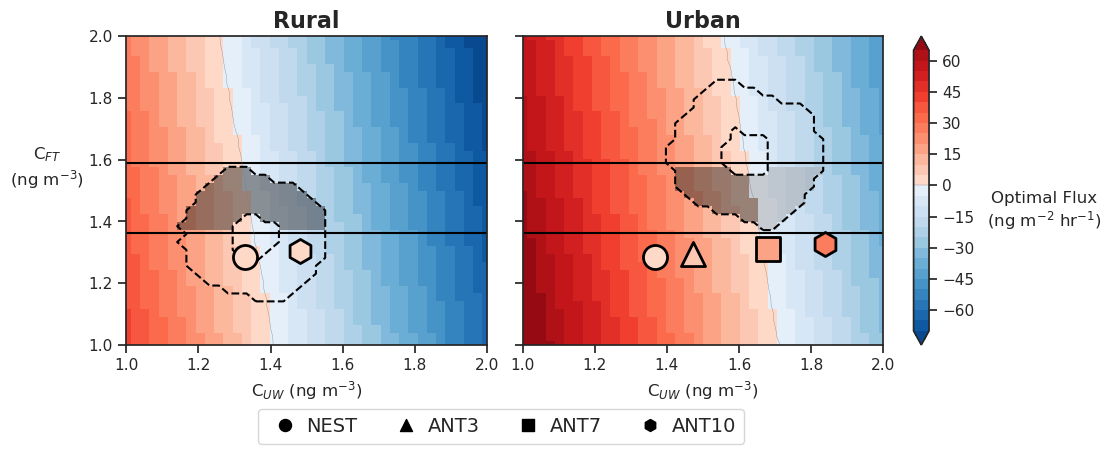

In [194]:
if figure4 == True:
    # -------------------------------------
    # --- Figure 4 plotting/compilation ---
    # -------------------------------------

    alpha = 0.4

    bounds = np.arange(-70, 70, 5)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

    bounds_shade = np.array([0,0.8,0.9,1.6])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    fig,ax=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True,layout='constrained')
    g = ax[0].pcolormesh(uw_conc,ft_conc,rural_ss,norm=norm,cmap=cmap)

    g = ax[0].scatter(np.nanmean(rural_uw_n),np.nanmean(rural_ft_n),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    #ax[0].scatter(np.nanmean(rural_uw_n3x),np.nanmean(rural_ft_n3x),c=[r_f3x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2)
    #ax[0].scatter(np.nanmean(rural_uw_n7x),np.nanmean(rural_ft_n7x),c=[r_f7x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2)
    ax[0].scatter(np.nanmean(rural_uw_n10xnes),np.nanmean(rural_ft_n10xnes),c=[r_f10xnes],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[0].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[0].axhline(measurements['urban'].min(),c='black',linewidth=1.5)

    ax[0].contour(uw_conc,ft_conc,rural_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[0].contour(uw_conc,ft_conc,amp_space_rural,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[0].pcolormesh(uw_conc,ft_conc,test_rural,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    #ax[0].contourf(uw_conc,ft_conc,constrained_space_rural,alpha=alpha,levels=[0.9,1,1.5],colors=[shading[0],shading[1]],antialiased=True,corner_mask=False) #levels=[1,2,3],
    ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
    ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

    #now urban
    bounds_shade = np.array([0,0.9,1.4,2])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    
    g = ax[1].pcolormesh(uw_conc,ft_conc,urban_ss,norm=norm,cmap=cmap)

    #geoschem
    ax[1].scatter(np.nanmean(urban_uw_n),np.nanmean(urban_ft_n),c=[u_f],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[1].scatter(np.nanmean(urban_uw_n3xnes),np.nanmean(urban_ft_n3xnes),c=[u_f3xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7xnes),np.nanmean(urban_ft_n7xnes),c=[u_f7xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10xnes),np.nanmean(urban_ft_n10xnes),c=[u_f10xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[1].contour(uw_conc,ft_conc,urban_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[1].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[1].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[1].contour(uw_conc,ft_conc,amp_space_urban,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[1].pcolormesh(uw_conc,ft_conc,test_urban,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],

    ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

    cbar = fig.colorbar(g)
    cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=50)
    cbar.ax.axhline(0, c='gray',linewidth=0.25)
    
    #setting x/y lims
    ax[0].set_xlim(1,2)
    ax[0].set_ylim(1,2)
    
    #adding in a legend
    ax[1].scatter(-1,-1,c='black',s=300,marker='o',label='NEST')
    ax[1].scatter(-1,-1,c='black',s=300,marker='^',label='ANT3')
    ax[1].scatter(-1,-1,c='black',s=300,marker='s',label='ANT7')
    ax[1].scatter(-1,-1,c='black',s=300,marker='h',label='ANT10')

    fig.legend(loc='lower center',
               ncol=4,
               markerscale=0.5,
               bbox_to_anchor=(0.45,-0.12),
               columnspacing=1.5,
               handletextpad=0.1,
               fontsize=14,
               scatteryoffsets=[0.5])
    
    #adding in titles
    ax[0].set_title('Rural',fontsize=16,fontweight='bold')
    ax[1].set_title('Urban',fontsize=16,fontweight='bold')
    plt.savefig(figpath+'Fig4_EST.'+figformat,dpi=dpi,transparent=True,bbox_inches='tight')


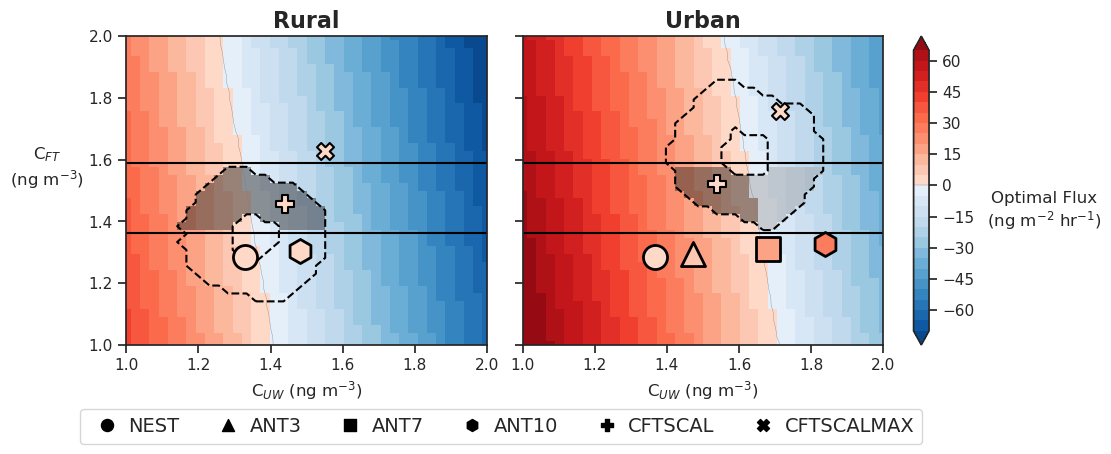

In [195]:
if figure4 == True:
    # -------------------------------------
    # --- Figure 4 plotting/compilation ---
    # -------------------------------------

    alpha = 0.4

    bounds = np.arange(-70, 70, 5)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

    bounds_shade = np.array([0,0.8,0.9,1.6])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    fig,ax=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True,layout='constrained')
    g = ax[0].pcolormesh(uw_conc,ft_conc,rural_ss,norm=norm,cmap=cmap)

    g = ax[0].scatter(np.nanmean(rural_uw_n),np.nanmean(rural_ft_n),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    #ax[0].scatter(np.nanmean(rural_uw_n3x),np.nanmean(rural_ft_n3x),c=[r_f3x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2)
    #ax[0].scatter(np.nanmean(rural_uw_n7x),np.nanmean(rural_ft_n7x),c=[r_f7x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2)
    ax[0].scatter(np.nanmean(rural_uw_n10xnes),np.nanmean(rural_ft_n10xnes),c=[r_f10xnes],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    #ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),marker='+',c='black',s=200)
    #ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),marker='2',c='black',s=200)
    ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')#,linestyle='-.')
    ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')#,linestyle=':')    
    
    ax[0].contour(uw_conc,ft_conc,rural_ss,levels=[0],colors='gray',linewidths=0.25)    
    ax[0].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[0].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[0].contour(uw_conc,ft_conc,amp_space_rural,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[0].pcolormesh(uw_conc,ft_conc,test_rural,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    #ax[0].contourf(uw_conc,ft_conc,constrained_space_rural,alpha=alpha,levels=[0.9,1,1.5],colors=[shading[0],shading[1]],antialiased=True,corner_mask=False) #levels=[1,2,3],
    ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
    ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

    #now urban
    bounds_shade = np.array([0,0.9,1.4,2])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    
    g = ax[1].pcolormesh(uw_conc,ft_conc,urban_ss,norm=norm,cmap=cmap)

    #geoschem
    ax[1].scatter(np.nanmean(urban_uw_n),np.nanmean(urban_ft_n),c=[u_f],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[1].scatter(np.nanmean(urban_uw_n3xnes),np.nanmean(urban_ft_n3xnes),c=[u_f3xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7xnes),np.nanmean(urban_ft_n7xnes),c=[u_f7xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10xnes),np.nanmean(urban_ft_n10xnes),c=[u_f10xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[1].contour(uw_conc,ft_conc,urban_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[1].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[1].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[1].contour(uw_conc,ft_conc,amp_space_urban,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[1].pcolormesh(uw_conc,ft_conc,test_urban,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],

    #ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),marker='+',c='black',s=200)
    #ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),marker='2',c='black',s=200)
    ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')#,linestyle='-.')
    ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')#,linestyle=':')    

    ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

    cbar = fig.colorbar(g)
    cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=50)
    cbar.ax.axhline(0, c='gray',linewidth=0.25)

    #setting x/y lims
    ax[0].set_xlim(1,2)
    ax[0].set_ylim(1,2)
    
    #adding in a legend
    ax[1].scatter(-1,-1,c='black',s=300,marker='o',label='NEST')
    ax[1].scatter(-1,-1,c='black',s=300,marker='^',label='ANT3')
    ax[1].scatter(-1,-1,c='black',s=300,marker='s',label='ANT7')
    ax[1].scatter(-1,-1,c='black',s=300,marker='h',label='ANT10')
    ax[1].scatter(-1,-1,c='black',s=300,marker='P',label='CFTSCAL')
    ax[1].scatter(-1,-1,c='black',s=300,marker='X',label='CFTSCALMAX')

    fig.legend(loc='lower center',
               ncol=6,
               markerscale=0.5,
               bbox_to_anchor=(0.45,-0.12),
               columnspacing=1.5,
               handletextpad=0.1,
               fontsize=14,
               scatteryoffsets=[0.5])
    
    ax[0].set_title('Rural',fontsize=16,fontweight='bold')
    ax[1].set_title('Urban',fontsize=16,fontweight='bold')

    
    plt.savefig(figpath+'Fig4_wFTscale_EST.'+figformat,dpi=dpi,transparent=True,bbox_inches='tight')


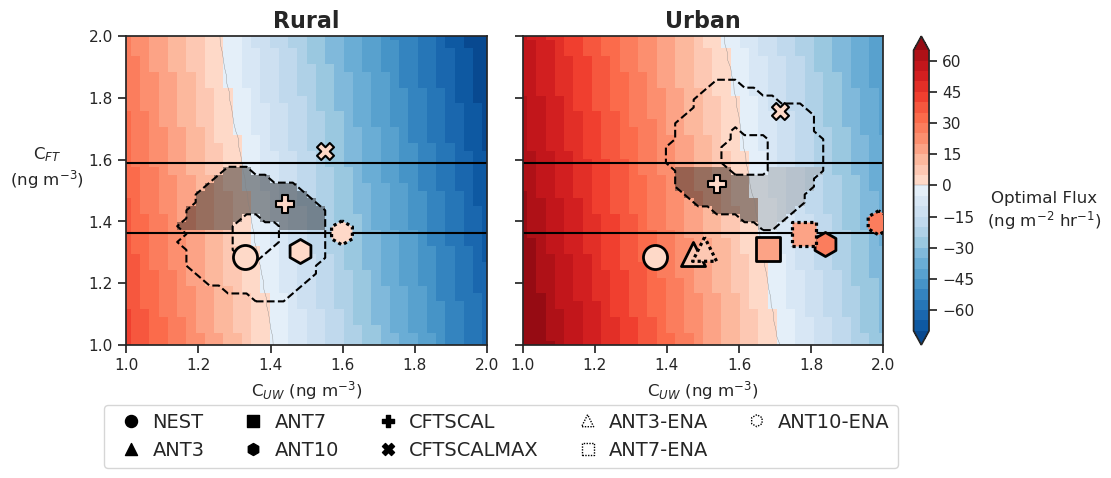

In [196]:
if figure4 == True:
    # -------------------------------------
    # --- Figure 3 plotting/compilation ---
    # -------------------------------------

    #now, lets make one two-panel plot featuring the urban and rural results.
    alpha = 0.4

    bounds = np.arange(-70, 70, 5)
    norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256,extend='both')

    bounds_shade = np.array([0,0.8,0.9,1.6])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    fig,ax=plt.subplots(1,2,figsize=(11,4),sharex=True,sharey=True,layout='constrained')
    g = ax[0].pcolormesh(uw_conc,ft_conc,rural_ss,norm=norm,cmap=cmap)

    #geoschem
    g = ax[0].scatter(np.nanmean(rural_uw_n),np.nanmean(rural_ft_n),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[0].scatter(np.nanmean(rural_uw_n10xnes),np.nanmean(rural_ft_n10xnes),c=[r_f10xnes],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')
    ax[0].scatter(np.nanmean(rural_uw_n10x),np.nanmean(rural_ft_n10x),c=[r_f10x],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='h')
    
    ax[0].contour(uw_conc,ft_conc,rural_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[0].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[0].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[0].contour(uw_conc,ft_conc,amp_space_rural,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[0].pcolormesh(uw_conc,ft_conc,test_rural,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],
    ax[0].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')
    ax[0].set_ylabel('C$_{FT}$\n(ng m$^{-3}$)',rotation=0,labelpad=30)

    #ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),marker='+',c='black',s=200)
    #ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),marker='2',c='black',s=200)
    
    ax[0].scatter(np.nanmean(rural_uw_ftscale),np.nanmean(rural_ft_ftscale),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')#,linestyle='-.')
    ax[0].scatter(np.nanmean(rural_uw_ftscale_t),np.nanmean(rural_ft_ftscale_t),c=[r_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')#,linestyle=':')    
    
    g = ax[1].pcolormesh(uw_conc,ft_conc,urban_ss,norm=norm,cmap=cmap)

    #geoschem
    ax[1].scatter(np.nanmean(urban_uw_n),np.nanmean(urban_ft_n),c=[u_f],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='o')
    ax[1].scatter(np.nanmean(urban_uw_n3xnes),np.nanmean(urban_ft_n3xnes),c=[u_f3xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7xnes),np.nanmean(urban_ft_n7xnes),c=[u_f7xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10xnes),np.nanmean(urban_ft_n10xnes),c=[u_f10xnes],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2,marker='h')

    ax[1].scatter(np.nanmean(urban_uw_n3x),np.nanmean(urban_ft_n3x),c=[u_f3x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='^')
    ax[1].scatter(np.nanmean(urban_uw_n7x),np.nanmean(urban_ft_n7x),c=[u_f7x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='s')
    ax[1].scatter(np.nanmean(urban_uw_n10x),np.nanmean(urban_ft_n10x),c=[u_f10x],cmap=cmap,norm=norm,zorder=10,edgecolors='black',s=300,linewidth=2.3,linestyle=(0, (1, 1)),marker='h')

    
    #now urban
    bounds_shade = np.array([0,0.9,1.4,2])
    norm_shade = colors.BoundaryNorm(boundaries=bounds_shade, ncolors=256)

    
    ax[1].contour(uw_conc,ft_conc,urban_ss,levels=[0],colors='gray',linewidths=0.25)
    ax[1].axhline(measurements['rural'].max(),c='black',linewidth=1.5)
    ax[1].axhline(measurements['urban'].min(),c='black',linewidth=1.5)
    ax[1].contour(uw_conc,ft_conc,amp_space_urban,levels=[1.5,2.5],colors='black',linestyles='--')
    ax[1].pcolormesh(uw_conc,ft_conc,test_urban,alpha=alpha,norm=norm_shade,cmap='Greys') #levels=[1,2,3],

    #ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),marker='+',c='black',s=200)
    #ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),marker='2',c='black',s=200)

    ax[1].scatter(np.nanmean(urban_uw_ftscale),np.nanmean(urban_ft_ftscale),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='X')
    ax[1].scatter(np.nanmean(urban_uw_ftscale_t),np.nanmean(urban_ft_ftscale_t),c=[u_f],cmap=cmap,norm=g.norm,zorder=10,edgecolors='black',s=150,linewidth=1.5,marker='P')
    
    ax[1].set_xlabel('C$_{UW}$ (ng m$^{-3}$)')

    cbar = fig.colorbar(g)
    cbar.set_label('Optimal Flux\n(ng m$^{-2}$ hr$^{-1}$)',rotation=0,labelpad=50)
    cbar.ax.axhline(0, c='gray',linewidth=0.25)

    #setting x/y lims
    ax[0].set_xlim(1,2)
    ax[0].set_ylim(1,2)
    
    #adding in a legend
    ax[1].scatter(-1,-1,c='black',s=300,marker='o',label='NEST')
    ax[1].scatter(-1,-1,c='black',s=300,marker='^',label='ANT3')
    ax[1].scatter(-1,-1,c='black',s=300,marker='s',label='ANT7')
    ax[1].scatter(-1,-1,c='black',s=300,marker='h',label='ANT10')
    ax[1].scatter(-1,-1,c='black',s=300,marker='P',label='CFTSCAL')
    ax[1].scatter(-1,-1,c='black',s=300,marker='X',label='CFTSCALMAX')
    ax[1].scatter(-1,-1,c='white',edgecolor='black',s=300,marker='^',linestyle=(0, (1, 1)),label='ANT3-ENA')
    ax[1].scatter(-1,-1,c='white',edgecolor='black',s=300,marker='s',linestyle=(0, (1, 1)),label='ANT7-ENA')
    ax[1].scatter(-1,-1,c='white',edgecolor='black',s=300,marker='h',linestyle=(0, (1, 1)),label='ANT10-ENA')
    
    fig.legend(loc='lower center',
               ncol=5,
               markerscale=0.5,
               bbox_to_anchor=(0.45,-0.18),
               columnspacing=1.5,
               handletextpad=0.1,
               fontsize=14,
               scatteryoffsets=[0.5])

    ax[0].set_title('Rural',fontsize=16,fontweight='bold')
    ax[1].set_title('Urban',fontsize=16,fontweight='bold')

    plt.savefig(figpath+'Fig4_ENA_EST.'+figformat,dpi=dpi,transparent=True,bbox_inches='tight')


In [197]:
(np.nanmean(rural_ft_ftscale)-np.nanmean(rural_ft_n))/np.nanmean(rural_ft_n)*100

26.74513657600146

In [198]:
(np.nanmean(rural_ft_ftscale_t)-np.nanmean(rural_ft_n))/np.nanmean(rural_ft_n)*100

13.380433002221393

In [199]:
#now calculating percentage increases for manuscript
if figure4 == True:
    u = np.nanmean(rural_uw_n)
    us = np.nanmean(rural_uw_n10xnes)
    temp = (us-u)/u
    print('Rural % increase of uw concentrations: '+str(temp*100))

    u = np.nanmean(rural_ft_n)
    us = np.nanmean(rural_ft_n10xnes)
    temp = (us-u)/u
    print('Rural % increase of ft concentrations: '+str(temp*100))
  
    u = np.nanmean(urban_uw_n)
    us = np.nanmean(urban_uw_n10xnes)
    temp = (us-u)/u
    print('Urban % increase of uw concentrations: '+str(temp*100))

    u = np.nanmean(urban_ft_n)
    us = np.nanmean(urban_ft_n10xnes)
    temp = (us-u)/u
    print('Urban % increase of ft concentrations: '+str(temp*100))


Rural % increase of uw concentrations: 11.52040393239182
Rural % increase of ft concentrations: 1.4981371220823378
Urban % increase of uw concentrations: 34.42666634214924
Urban % increase of ft concentrations: 3.1291923197499814


In [200]:
u_f

array([2.885539], dtype=float32)

In [201]:
u_f10xnes

array([25.789722], dtype=float32)

In [202]:
#comparing fluxes
if figure4 == True:
    u = r_f
    us = r_f10x
    temp = us/u
    print('Rural change of net flux: '+str(temp))

    u = u_f
    us = u_f10x
    temp = us/u
    print('Urban change of net flux: '+str(temp))


Rural change of net flux: [2.0448449]
Urban change of net flux: [8.931131]


In [203]:
if figure4 == True:
    u = np.nanmean(rural_uw_n)
    us = np.nanmean(rural_uw_n10x)
    temp = (us-u)/u
    print('Rural % increase of uw concentrations (ENA): '+str(temp*100))

    u = np.nanmean(rural_ft_n)
    us = np.nanmean(rural_ft_n10x)
    temp = (us-u)/u
    print('Rural % increase of ft concentrations (ENA): '+str(temp*100))
  
    u = np.nanmean(urban_uw_n)
    us = np.nanmean(urban_uw_n10x)
    temp = (us-u)/u
    print('Urban % increase of uw concentrations (ENA): '+str(temp*100))

    u = np.nanmean(urban_ft_n)
    us = np.nanmean(urban_ft_n10x)
    temp = (us-u)/u
    print('Urban % increase of ft concentrations (ENA): '+str(temp*100))


Rural % increase of uw concentrations (ENA): 20.271914775119814
Rural % increase of ft concentrations (ENA): 6.05401126391218
Urban % increase of uw concentrations (ENA): 45.37505991404269
Urban % increase of ft concentrations (ENA): 8.565888860761014
